# ============================================================
# PHARMALENS AI
# NOTEBOOK 07 — COMPANY INTELLIGENCE
# ============================================================

# Company-level pharmaceutical market intelligence
# Dataset: Egypt Pharmaceutical Market 2021–2025
#
# Main objectives:
# 1. Manufacturer performance
# 2. Company market share
# 3. Company growth
# 4. Company portfolio strength
# 5. Brand portfolio analysis
# 6. Therapeutic exposure
# 7. Launch activity
# 8. Channel strength
# 9. Pricing intelligence
# 10. Competitive benchmarking
# 11. Company strategic segmentation
# 12. Company opportunity scoring
# 13. Executive dashboard
# ============================================================

In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df=  pd.read_excel ("IMS (2021-2025).xlsx")

In [5]:
df = df.rename(columns={
    "Sector": "Distribution Channel",
    "ATC4": "Therapeutic Class",
    "Corporation": "Manufacturer",
    "Product": "Brand Name",
    "Pack": "Pack Size",
    "Launch Date": "Product Launch",
    "Strength": "Drug Strength",
    "Retail Price": "Selling Price",
    "NFC3": "Market Category",
    "Period": "Month",
    "Calendar Year": "Year",
    "Units": "Sales Units",
    "LC Value": "Sales Value"
})

In [6]:
# ============================================================
# 3. EXPECTED COLUMN VALIDATION
# ============================================================

expected_columns = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Pack Size",
    "Product Launch",
    "Drug Strength",
    "Selling Price",
    "Market Category",
    "Month",
    "Year",
    "Sales Units",
    "Sales Value"
]

missing_columns = [
    col for col in expected_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
    raise ValueError("Required columns are missing from the dataframe.")

print("All required columns are available.")

All required columns are available.


In [7]:
# ============================================================
# 4. DATA TYPE CLEANING
# ============================================================

numeric_columns = [
    "Selling Price",
    "Sales Units",
    "Sales Value",
    "Year"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Date conversion
df["Month"] = pd.to_datetime(
    df["Month"],
    errors="coerce"
)

df["Product Launch"] = pd.to_datetime(
    df["Product Launch"],
    errors="coerce"
)

print(df.dtypes)

Distribution Channel            object
Therapeutic Class               object
Manufacturer                    object
Brand Name                      object
Pack Size                       object
Product Launch          datetime64[ns]
Drug Strength                   object
Selling Price                  float64
Market Category                 object
Month                   datetime64[ns]
Year                             int64
Sales Units                    float64
Sales Value                    float64
dtype: object


In [8]:
# ============================================================
# 5. BASIC DATA QUALITY CHECK
# ============================================================

quality_check = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isna().sum(),
    "Missing %": df.isna().mean() * 100,
    "Unique Values": df.nunique()
})

quality_check = quality_check.sort_values(
    "Missing %",
    ascending=False
)

display(quality_check)

,Column,Missing Values,Missing %,Unique Values
Product Launch,Product Launch,9335,1.025912,468
Distribution Channel,Distribution Channel,0,0.000000,2
Therapeutic Class,Therapeutic Class,0,0.000000,513
Manufacturer,Manufacturer,0,0.000000,1396
Brand Name,Brand Name,0,0.000000,9958
Pack Size,Pack Size,0,0.000000,8835
Drug Strength,Drug Strength,0,0.000000,459
Selling Price,Selling Price,0,0.000000,1999
Market Category,Market Category,0,0.000000,209
Month,Month,0,0.000000,60


In [9]:
# ============================================================
# 6. CLEAN TEXT FIELDS
# ============================================================

text_columns = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Pack Size",
    "Drug Strength",
    "Market Category"
]

for col in text_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
    )

print("Text fields cleaned.")

Text fields cleaned.


In [10]:
# ============================================================
# 7. REMOVE INVALID SALES RECORDS
# ============================================================

df_company = df.copy()

df_company = df_company[
    df_company["Manufacturer"].notna()
]

df_company = df_company[
    df_company["Sales Value"].notna()
]

df_company = df_company[
    df_company["Sales Value"] >= 0
]

print("Company analysis dataset shape:", df_company.shape)

Company analysis dataset shape: (909922, 13)


In [11]:
# ============================================================
# 8. TOTAL MARKET SIZE
# ============================================================

total_market_sales = df_company["Sales Value"].sum()
total_market_units = df_company["Sales Units"].sum()

print(f"Total Market Sales Value: {total_market_sales:,.2f}")
print(f"Total Market Units: {total_market_units:,.0f}")

Total Market Sales Value: 882,881,495,960.49
Total Market Units: 15,310,411,499


In [12]:
# ============================================================
# 9. MANUFACTURER SALES
# ============================================================

manufacturer_sales = (
    df_company
    .groupby("Manufacturer", as_index=False)
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum")
    )
    .sort_values(
        "Sales_Value",
        ascending=False
    )
)

manufacturer_sales["Market_Share_%"] = (
    manufacturer_sales["Sales_Value"]
    / total_market_sales
    * 100
)

display(manufacturer_sales.head(20))

,Manufacturer,Sales_Value,Sales_Units,Market_Share_%
991,PHARCO*,4.286563e+10,1.367007e+09,4.855197
1157,SANOFI,3.950244e+10,6.511505e+08,4.474263
97,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065
901,NOVARTIS,2.979254e+10,3.468835e+08,3.374466
382,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105
498,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465
431,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896
759,MARCYRL*,2.244227e+10,2.892759e+08,2.541935
105,APEX PHARMA*,2.048389e+10,3.071037e+08,2.320118
147,AUG PHARMA*,2.046888e+10,2.625579e+08,2.318417


In [13]:
# ============================================================
# 10. TOP 20 MANUFACTURERS BY SALES
# ============================================================

top20_manufacturers = (
    manufacturer_sales
    .head(20)
    .copy()
)

display(top20_manufacturers)

,Manufacturer,Sales_Value,Sales_Units,Market_Share_%
991,PHARCO*,4.286563e+10,1.367007e+09,4.855197
1157,SANOFI,3.950244e+10,6.511505e+08,4.474263
97,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065
901,NOVARTIS,2.979254e+10,3.468835e+08,3.374466
382,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105
498,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465
431,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896
759,MARCYRL*,2.244227e+10,2.892759e+08,2.541935
105,APEX PHARMA*,2.048389e+10,3.071037e+08,2.320118
147,AUG PHARMA*,2.046888e+10,2.625579e+08,2.318417


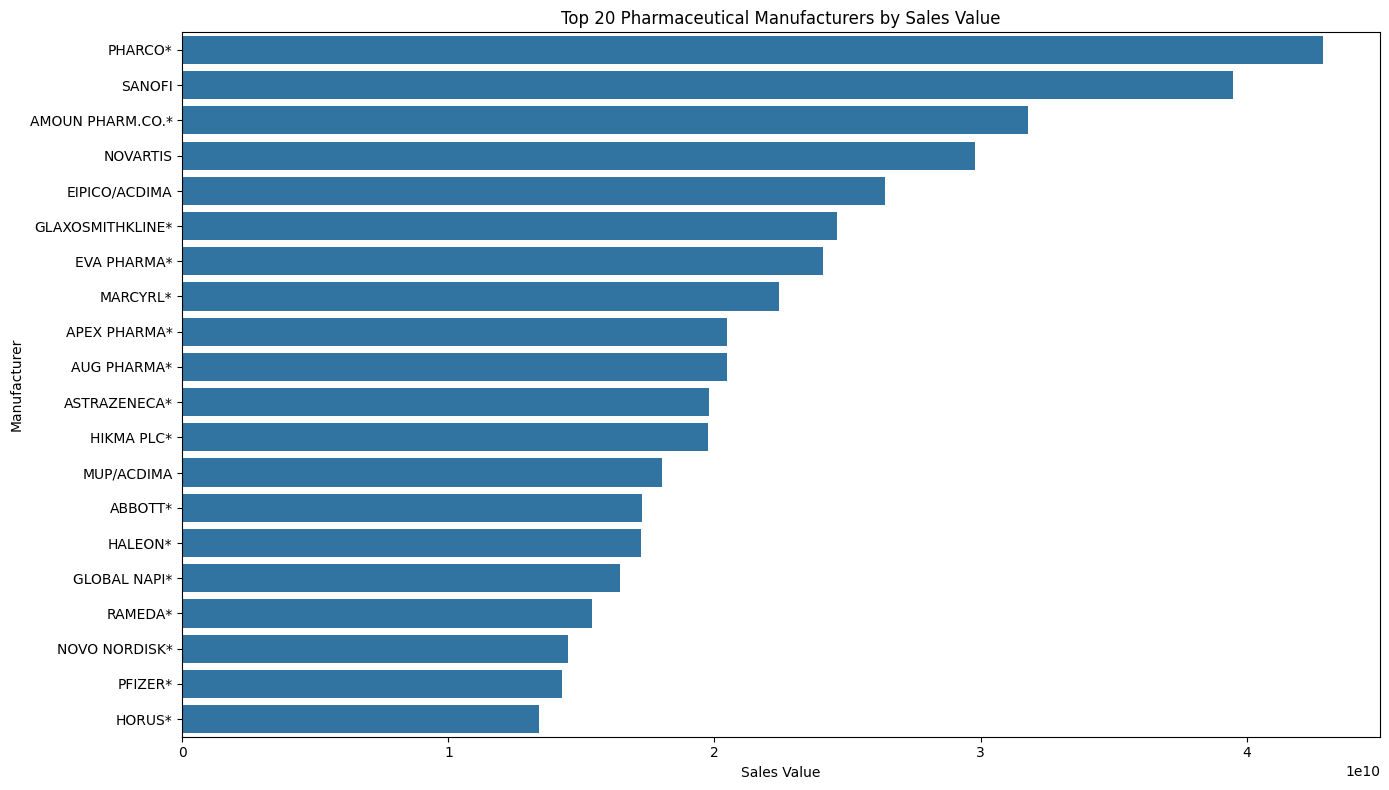

In [14]:
# ============================================================
# 11. TOP MANUFACTURER VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top20_manufacturers,
    y="Manufacturer",
    x="Sales_Value"
)

plt.title(
    "Top 20 Pharmaceutical Manufacturers by Sales Value"
)

plt.xlabel("Sales Value")
plt.ylabel("Manufacturer")

plt.tight_layout()
plt.show()

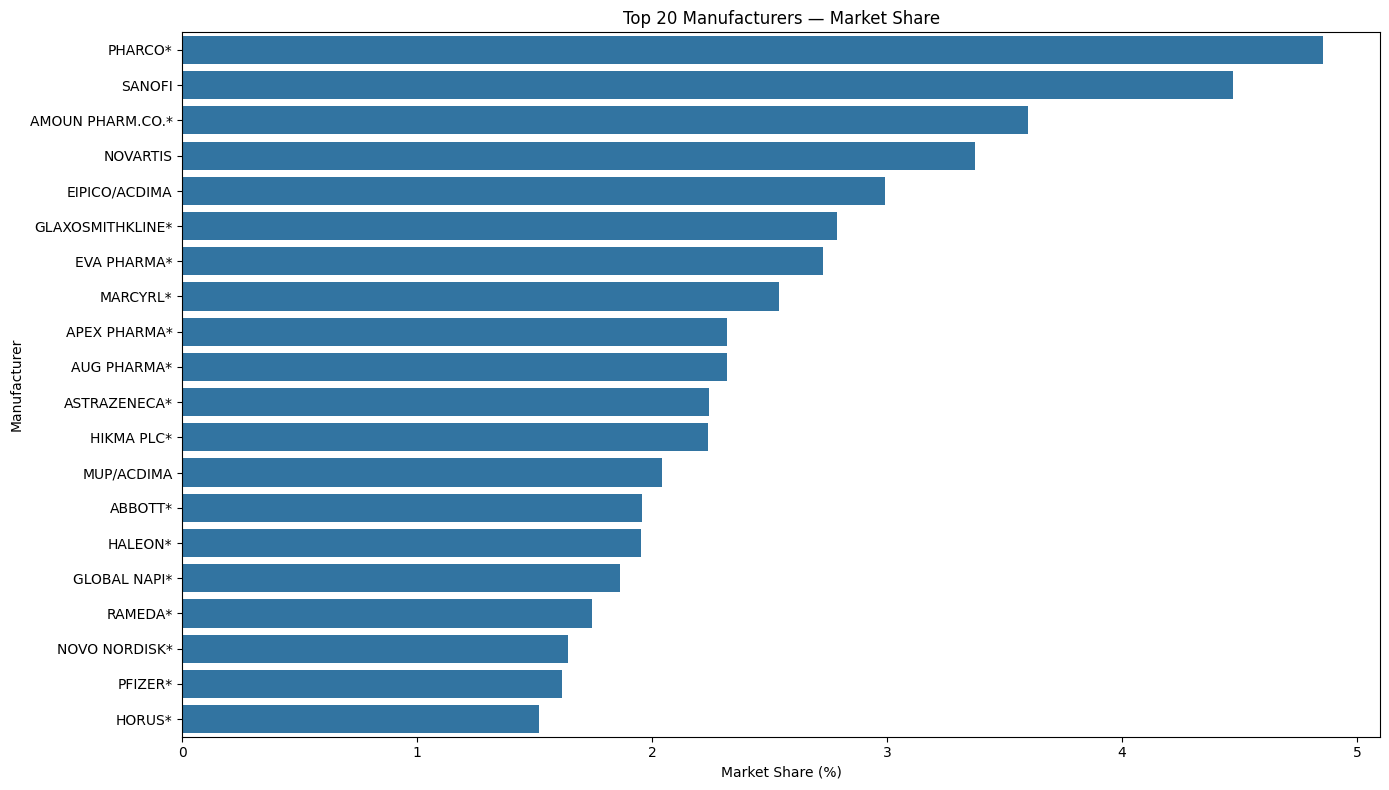

In [15]:
# ============================================================
# 12. MANUFACTURER MARKET SHARE
# ============================================================

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top20_manufacturers,
    y="Manufacturer",
    x="Market_Share_%"
)

plt.title(
    "Top 20 Manufacturers — Market Share"
)

plt.xlabel("Market Share (%)")
plt.ylabel("Manufacturer")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 13. YEARLY MANUFACTURER SALES
# ============================================================

manufacturer_yearly = (
    df_company
    .groupby(
        ["Year", "Manufacturer"],
        as_index=False
    )
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum")
    )
)

display(manufacturer_yearly.head())

,Year,Manufacturer,Sales_Value,Sales_Units
0,2021,15 MAY PHARMACEUTICAL,1.651000e+05,2540.0
1,2021,A.S.A*,3.630000e+02,22.0
2,2021,AB ONE PHARMA,5.628750e+04,3950.0
3,2021,ABBOTT*,1.955710e+09,44985814.0
4,2021,ABBVIE*,7.551664e+07,239200.0


In [17]:
# ============================================================
# 14. COMPANY GROWTH ANALYSIS
# ============================================================

company_yearly_pivot = (
    manufacturer_yearly
    .pivot(
        index="Manufacturer",
        columns="Year",
        values="Sales_Value"
    )
    .fillna(0)
)

years_available = sorted(
    df_company["Year"]
    .dropna()
    .unique()
)

print("Years available:", years_available)

Years available: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [18]:
# ============================================================
# 15. YEAR-OVER-YEAR COMPANY GROWTH
# ============================================================

for i in range(1, len(years_available)):

    previous_year = years_available[i - 1]
    current_year = years_available[i]

    company_yearly_pivot[
        f"Growth_{previous_year}_{current_year}_%"
    ] = np.where(
        company_yearly_pivot[previous_year] > 0,
        (
            (
                company_yearly_pivot[current_year]
                / company_yearly_pivot[previous_year]
            ) - 1
        ) * 100,
        np.nan
    )

display(company_yearly_pivot.head())

Year,2021,2022,2023,2024,2025,Growth_2021_2022_%,Growth_2022_2023_%,Growth_2023_2024_%,Growth_2024_2025_%
Manufacturer,,,,,,,,,
15 MAY PHARMACEUTICAL,165100.0,49916.75,3185.0,26100.0,20600.0,-69.765748,-93.619376,719.466248,-21.072797
2M WHITES,0.0,0.00,0.0,0.0,5035151.0,NaN,NaN,NaN,NaN
2MS PHARMA,0.0,0.00,0.0,0.0,13075.0,NaN,NaN,NaN,NaN
3A,0.0,0.00,0.0,0.0,360.0,NaN,NaN,NaN,NaN
4S PHARMA*,0.0,0.00,0.0,81345.0,160493.0,NaN,NaN,NaN,97.299158


In [19]:
# ============================================================
# 16. COMPANY CAGR
# ============================================================

first_year = years_available[0]
last_year = years_available[-1]

company_growth = company_yearly_pivot.copy()

if (
    first_year in company_growth.columns
    and last_year in company_growth.columns
):

    number_of_years = last_year - first_year

    company_growth["CAGR_%"] = np.where(
        company_growth[first_year] > 0,
        (
            (
                company_growth[last_year]
                / company_growth[first_year]
            ) ** (1 / number_of_years)
            - 1
        ) * 100,
        np.nan
    )

display(
    company_growth[
        [first_year, last_year, "CAGR_%"]
    ]
    .sort_values(
        "CAGR_%",
        ascending=False
    )
    .head(20)
)

Year,2021,2025,CAGR_%
Manufacturer,,,
BIONORICA*,1210.50,1.370513e+08,1734.338898
BENDALIS*,2352.00,8.034530e+06,664.505809
INAD PHARMA*,23251.50,3.189798e+07,508.594519
ADAPT PHARMA*,100.00,1.065000e+05,471.264717
RIMOS PH.*,12980.00,1.065913e+07,435.317901
LO.LI.PHARMA*,546360.00,1.195305e+08,284.591786
ORPHAN PH.*,6720.00,1.182865e+06,264.243220
PHARMACREDO*,281923.90,4.861879e+07,262.383213
REXCEL*,11806.50,1.979496e+06,259.839110


In [20]:
# ============================================================
# 17. COMPANY PORTFOLIO SIZE
# ============================================================

company_portfolio = (
    df_company
    .groupby("Manufacturer")
    .agg(
        Brand_Count=("Brand Name", "nunique"),
        Therapeutic_Class_Count=(
            "Therapeutic Class",
            "nunique"
        ),
        Market_Category_Count=(
            "Market Category",
            "nunique"
        ),
        Distribution_Channel_Count=(
            "Distribution Channel",
            "nunique"
        )
    )
    .reset_index()
)

display(
    company_portfolio
    .sort_values(
        "Brand_Count",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count
991,PHARCO*,310,164,60,2
382,EIPICO/ACDIMA,186,112,45,2
504,GLOBAL NAPI*,176,107,38,2
431,EVA PHARMA*,173,112,37,2
759,MARCYRL*,167,107,38,2
563,HEFNY GROUP*,154,86,34,2
585,HIKMA PLC*,153,105,38,2
97,AMOUN PHARM.CO.*,127,109,36,2
770,MASH*,123,76,23,2
851,MUP/ACDIMA,117,87,45,2


In [21]:
# ============================================================
# 18. COMPANY SALES + PORTFOLIO
# ============================================================

company_intelligence = manufacturer_sales.merge(
    company_portfolio,
    on="Manufacturer",
    how="left"
)

if "CAGR_%" in company_growth.columns:

    company_growth_selected = (
        company_growth[
            ["CAGR_%"]
        ]
        .reset_index()
    )

    company_intelligence = company_intelligence.merge(
        company_growth_selected,
        on="Manufacturer",
        how="left"
    )

display(company_intelligence.head(20))

,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,CAGR_%
0,PHARCO*,4.286563e+10,1.367007e+09,4.855197,310,164,60,2,26.778554
1,SANOFI,3.950244e+10,6.511505e+08,4.474263,97,78,41,2,23.616275
2,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065,127,109,36,2,20.533551
3,NOVARTIS,2.979254e+10,3.468835e+08,3.374466,84,49,30,2,19.139160
4,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105,186,112,45,2,21.602265
5,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465,96,68,39,2,23.391065
6,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896,173,112,37,2,27.053784
7,MARCYRL*,2.244227e+10,2.892759e+08,2.541935,167,107,38,2,40.024885
8,APEX PHARMA*,2.048389e+10,3.071037e+08,2.320118,76,57,22,2,28.079266
9,AUG PHARMA*,2.046888e+10,2.625579e+08,2.318417,89,58,28,2,33.039853


In [22]:
# ============================================================
# 19. SALES PER BRAND
# ============================================================

company_intelligence["Sales_per_Brand"] = (
    company_intelligence["Sales_Value"]
    / company_intelligence["Brand_Count"]
)

display(
    company_intelligence
    .sort_values(
        "Sales_per_Brand",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,CAGR_%,Sales_per_Brand
87,ROWA WAGNER*,1.840197e+09,3.784490e+07,0.208431,2,2,1,2,25.279811,9.200985e+08
38,ACINO*,6.876169e+09,6.852298e+07,0.778833,8,6,11,2,24.401710,8.595211e+08
116,ENGELHARD,7.998487e+08,1.906593e+07,0.090595,1,1,1,2,49.977264,7.998487e+08
117,ELERTE,7.776104e+08,3.091740e+07,0.088076,1,1,1,2,17.872308,7.776104e+08
14,HALEON*,1.722433e+10,4.924257e+08,1.950922,24,14,19,2,34.544005,7.176805e+08
17,NOVO NORDISK*,1.448079e+10,5.504044e+07,1.640174,22,12,9,2,41.745440,6.582178e+08
126,GELITA HEALTH*,6.541226e+08,3.107799e+06,0.074090,1,1,1,2,4.853458,6.541226e+08
90,NUTRIBIO*,1.537197e+09,1.208859e+07,0.174111,3,1,1,2,30.987347,5.123991e+08
43,VITABIOTICS*,6.033060e+09,6.125149e+07,0.683337,14,9,8,2,29.086422,4.309329e+08
10,ASTRAZENECA*,1.979251e+10,9.392758e+07,2.241809,46,40,22,2,30.090077,4.302721e+08


In [23]:
# ============================================================
# 20. COMPANY BRAND CONCENTRATION
# ============================================================

company_brand_sales = (
    df_company
    .groupby(
        ["Manufacturer", "Brand Name"],
        as_index=False
    )
    .agg(
        Sales_Value=("Sales Value", "sum")
    )
)

company_brand_sales["Brand_Rank"] = (
    company_brand_sales
    .groupby("Manufacturer")["Sales_Value"]
    .rank(
        method="first",
        ascending=False
    )
)

top_brand_sales = (
    company_brand_sales[
        company_brand_sales["Brand_Rank"] == 1
    ]
    .copy()
)

top_brand_sales = top_brand_sales.rename(
    columns={
        "Sales_Value": "Top_Brand_Sales"
    }
)

company_intelligence = company_intelligence.merge(
    top_brand_sales[
        [
            "Manufacturer",
            "Brand Name",
            "Top_Brand_Sales"
        ]
    ],
    on="Manufacturer",
    how="left"
)

company_intelligence["Top_Brand_Contribution_%"] = (
    company_intelligence["Top_Brand_Sales"]
    / company_intelligence["Sales_Value"]
    * 100
)

display(
    company_intelligence[
        [
            "Manufacturer",
            "Brand Name",
            "Top_Brand_Sales",
            "Top_Brand_Contribution_%"
        ]
    ]
    .sort_values(
        "Top_Brand_Sales",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Brand Name,Top_Brand_Sales,Top_Brand_Contribution_%
9,AUG PHARMA*,ZURCAL,7.804095e+09,38.126635
5,GLAXOSMITHKLINE*,AUGMENTIN,6.813283e+09,27.684999
38,ACINO*,CONTROLOC,6.360948e+09,92.507142
14,HALEON*,PANADOL,6.048820e+09,35.117880
1,SANOFI,CLEXANE,5.555901e+09,14.064705
21,BIOMED PHARMA.*,GABIMASH,5.308934e+09,48.978952
13,ABBOTT*,BRUFEN,5.189706e+09,30.042026
2,AMOUN PHARM.CO.*,HIBIOTIC,5.093675e+09,16.034661
6,EVA PHARMA*,CONVENTIN,4.798667e+09,19.939254
17,NOVO NORDISK*,INS MIXTARD 30 HM,3.722087e+09,25.703617


In [24]:
# ============================================================
# 21. COMPANY THERAPEUTIC CLASS EXPOSURE
# ============================================================

company_therapeutic = (
    df_company
    .groupby(
        [
            "Manufacturer",
            "Therapeutic Class"
        ],
        as_index=False
    )
    .agg(
        Sales_Value=("Sales Value", "sum")
    )
)

company_therapeutic["Therapeutic_Share_%"] = (
    company_therapeutic
    .groupby("Manufacturer")["Sales_Value"]
    .transform("sum")
)

company_therapeutic["Therapeutic_Share_%"] = (
    company_therapeutic["Sales_Value"]
    / company_therapeutic["Therapeutic_Share_%"]
    * 100
)

display(
    company_therapeutic
    .sort_values(
        "Sales_Value",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Therapeutic Class,Sales_Value,Therapeutic_Share_%
5173,NOVARTIS,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024
950,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,9.326375e+09,45.563685
3169,HERO*,V06C1 INFANT MILKS,7.622353e+09,91.138022
5008,NESTLE*,V06C1 INFANT MILKS,7.587873e+09,79.613018
5298,NUTRICIA*,V06C1 INFANT MILKS,7.358919e+09,99.548138
2659,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,6.813630e+09,27.686413
2937,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,6.791115e+09,39.427453
94,ACINO*,A02B2 PROTON PUMP INHIBITORS,6.361029e+09,92.508323
657,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290
6694,SANOFI,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705


In [25]:
# ============================================================
# 22. TOP THERAPEUTIC CLASS FOR EACH COMPANY
# ============================================================

company_therapeutic["Therapeutic_Rank"] = (
    company_therapeutic
    .groupby("Manufacturer")["Sales_Value"]
    .rank(
        method="first",
        ascending=False
    )
)

company_top_therapeutic = (
    company_therapeutic[
        company_therapeutic["Therapeutic_Rank"] == 1
    ]
    .copy()
)

company_top_therapeutic = company_top_therapeutic.rename(
    columns={
        "Therapeutic Class": "Top_Therapeutic_Class",
        "Sales_Value": "Top_Therapeutic_Sales",
        "Therapeutic_Share_%": "Top_Therapeutic_Share_%"
    }
)

company_intelligence = company_intelligence.merge(
    company_top_therapeutic[
        [
            "Manufacturer",
            "Top_Therapeutic_Class",
            "Top_Therapeutic_Sales",
            "Top_Therapeutic_Share_%"
        ]
    ],
    on="Manufacturer",
    how="left"
)

display(
    company_intelligence[
        [
            "Manufacturer",
            "Top_Therapeutic_Class",
            "Top_Therapeutic_Sales",
            "Top_Therapeutic_Share_%"
        ]
    ].head(20)
)

,Manufacturer,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%
0,PHARCO*,J01D2 CEPHALOSPORINS INJECT,3.386047e+09,7.899212
1,SANOFI,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705
2,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290
3,NOVARTIS,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024
4,EIPICO/ACDIMA,J01D2 CEPHALOSPORINS INJECT,5.171401e+09,19.595871
5,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,6.813630e+09,27.686413
6,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,5.055669e+09,21.007139
7,MARCYRL*,C10C0 LIP.REG.CO.W.OTH.LIP.REG,2.852656e+09,12.711083
8,APEX PHARMA*,C09D3 AT2 ANTG COMB CALC ANTAG,2.721415e+09,13.285633
9,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,9.326375e+09,45.563685


In [26]:
# ============================================================
# 23. COMPANY DISTRIBUTION CHANNEL STRENGTH
# ============================================================

company_channel = (
    df_company
    .groupby(
        [
            "Manufacturer",
            "Distribution Channel"
        ],
        as_index=False
    )
    .agg(
        Sales_Value=("Sales Value", "sum")
    )
)

company_channel["Channel_Share_%"] = (
    company_channel["Sales_Value"]
    / company_channel
        .groupby("Manufacturer")["Sales_Value"]
        .transform("sum")
    * 100
)

display(
    company_channel
    .sort_values(
        "Sales_Value",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Distribution Channel,Sales_Value,Channel_Share_%
1499,NOVARTIS,PHARMACIES,2.846888e+10,95.557082
1937,SANOFI,PHARMACIES,2.794086e+10,70.731994
162,AMOUN PHARM.CO.*,PHARMACIES,2.309123e+10,72.690145
1652,PHARCO*,STORES,2.172784e+10,50.688258
1651,PHARCO*,PHARMACIES,2.113779e+10,49.311742
640,EIPICO/ACDIMA,PHARMACIES,2.011570e+10,76.223977
227,ASTRAZENECA*,PHARMACIES,1.810639e+10,91.480994
720,EVA PHARMA*,PHARMACIES,1.745321e+10,72.520984
1266,MARCYRL*,PHARMACIES,1.597698e+10,71.191465
833,GLAXOSMITHKLINE*,PHARMACIES,1.576259e+10,64.049482


In [27]:
# ============================================================
# 24. DOMINANT CHANNEL FOR EACH COMPANY
# ============================================================

company_channel["Channel_Rank"] = (
    company_channel
    .groupby("Manufacturer")["Sales_Value"]
    .rank(
        method="first",
        ascending=False
    )
)

dominant_channel = (
    company_channel[
        company_channel["Channel_Rank"] == 1
    ]
    .copy()
)

dominant_channel = dominant_channel.rename(
    columns={
        "Distribution Channel": "Dominant_Channel",
        "Sales_Value": "Dominant_Channel_Sales",
        "Channel_Share_%": "Dominant_Channel_Share_%"
    }
)

company_intelligence = company_intelligence.merge(
    dominant_channel[
        [
            "Manufacturer",
            "Dominant_Channel",
            "Dominant_Channel_Sales",
            "Dominant_Channel_Share_%"
        ]
    ],
    on="Manufacturer",
    how="left"
)

display(
    company_intelligence[
        [
            "Manufacturer",
            "Dominant_Channel",
            "Dominant_Channel_Share_%"
        ]
    ].head(20)
)

,Manufacturer,Dominant_Channel,Dominant_Channel_Share_%
0,PHARCO*,STORES,50.688258
1,SANOFI,PHARMACIES,70.731994
2,AMOUN PHARM.CO.*,PHARMACIES,72.690145
3,NOVARTIS,PHARMACIES,95.557082
4,EIPICO/ACDIMA,PHARMACIES,76.223977
5,GLAXOSMITHKLINE*,PHARMACIES,64.049482
6,EVA PHARMA*,PHARMACIES,72.520984
7,MARCYRL*,PHARMACIES,71.191465
8,APEX PHARMA*,PHARMACIES,60.541990
9,AUG PHARMA*,STORES,72.835299


In [28]:
# ============================================================
# 25. COMPANY PRICING INTELLIGENCE
# ============================================================

company_pricing = (
    df_company
    .groupby("Manufacturer", as_index=False)
    .agg(
        Average_Selling_Price=("Selling Price", "mean"),
        Median_Selling_Price=("Selling Price", "median"),
        Min_Selling_Price=("Selling Price", "min"),
        Max_Selling_Price=("Selling Price", "max")
    )
)

company_intelligence = company_intelligence.merge(
    company_pricing,
    on="Manufacturer",
    how="left"
)

display(company_pricing.head(20))

,Manufacturer,Average_Selling_Price,Median_Selling_Price,Min_Selling_Price,Max_Selling_Price
0,15 MAY PHARMACEUTICAL,200.000000,200.00,200.00,200.00
1,2M WHITES,131.018182,115.00,50.00,340.00
2,2MS PHARMA,93.571429,100.00,85.00,100.00
3,3A,60.000000,60.00,60.00,60.00
4,4S PHARMA*,84.521739,88.00,60.00,99.00
5,A.S.A*,16.500000,16.50,16.50,16.50
6,A2M MEDICAL*,120.000000,120.00,120.00,120.00
7,AB ONE PHARMA,14.250000,14.25,14.25,14.25
8,ABBOTT*,189.914183,130.00,4.50,1900.00
9,ABBVIE*,18147.810890,4934.00,4.20,116593.00


In [29]:
# ============================================================
# 26. COMPANY LAUNCH ACTIVITY
# ============================================================

company_launches = (
    df_company[
        df_company["Product Launch"].notna()
    ]
    .groupby("Manufacturer", as_index=False)
    .agg(
        Launch_Count=(
            "Brand Name",
            "nunique"
        )
    )
)

company_intelligence = company_intelligence.merge(
    company_launches,
    on="Manufacturer",
    how="left"
)

company_intelligence["Launch_Count"] = (
    company_intelligence["Launch_Count"]
    .fillna(0)
)

display(
    company_intelligence[
        [
            "Manufacturer",
            "Launch_Count"
        ]
    ]
    .sort_values(
        "Launch_Count",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Launch_Count
0,PHARCO*,310.0
4,EIPICO/ACDIMA,186.0
15,GLOBAL NAPI*,176.0
6,EVA PHARMA*,173.0
7,MARCYRL*,167.0
92,HEFNY GROUP*,154.0
11,HIKMA PLC*,153.0
2,AMOUN PHARM.CO.*,127.0
44,MASH*,123.0
12,MUP/ACDIMA,117.0


In [30]:
# ============================================================
# 27. RECENT LAUNCH ACTIVITY
# ============================================================

launch_data = df_company[
    df_company["Product Launch"].notna()
].copy()

launch_data["Launch_Year"] = (
    launch_data["Product Launch"]
    .dt.year
)

recent_launches = (
    launch_data[
        launch_data["Launch_Year"] >= 2024
    ]
    .groupby("Manufacturer", as_index=False)
    .agg(
        Recent_Launches=(
            "Brand Name",
            "nunique"
        )
    )
)

company_intelligence = company_intelligence.merge(
    recent_launches,
    on="Manufacturer",
    how="left"
)

company_intelligence["Recent_Launches"] = (
    company_intelligence["Recent_Launches"]
    .fillna(0)
)

display(
    company_intelligence[
        [
            "Manufacturer",
            "Recent_Launches"
        ]
    ]
    .sort_values(
        "Recent_Launches",
        ascending=False
    )
    .head(20)
)

,Manufacturer,Recent_Launches
92,HEFNY GROUP*,79.0
6,EVA PHARMA*,43.0
4,EIPICO/ACDIMA,37.0
45,COPAD*,34.0
31,LIMITLESS NATURALS,29.0
0,PHARCO*,28.0
274,UNIPRO SP.,28.0
7,MARCYRL*,27.0
15,GLOBAL NAPI*,26.0
21,BIOMED PHARMA.*,25.0


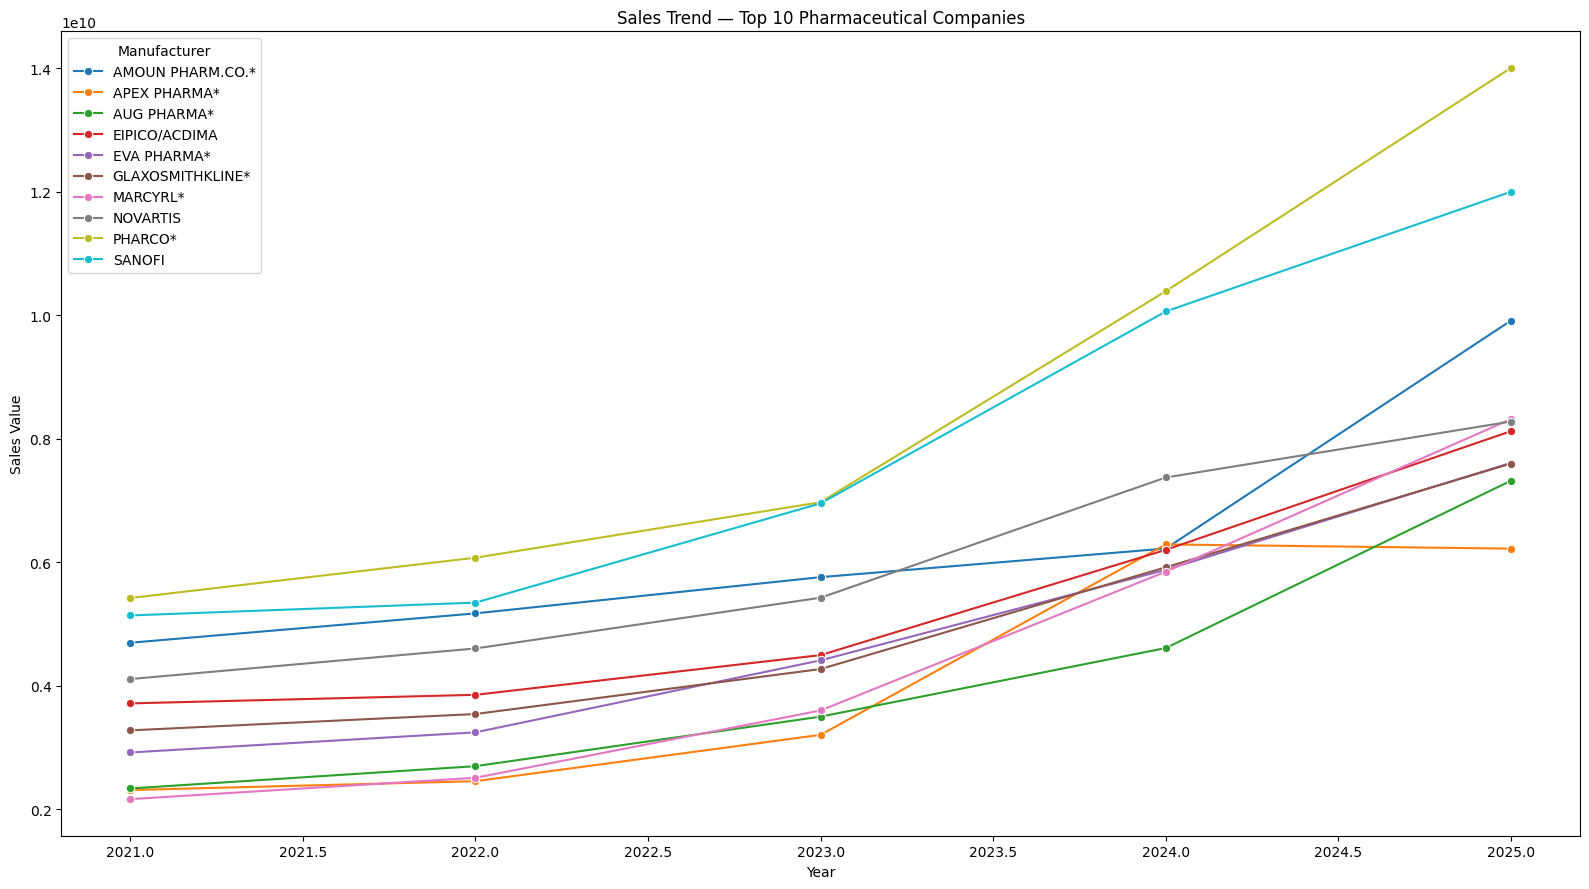

In [31]:
# ============================================================
# 28. COMPANY SALES TREND
# ============================================================

top_companies = (
    company_intelligence
    .nlargest(
        10,
        "Sales_Value"
    )["Manufacturer"]
    .tolist()
)

trend_top10 = manufacturer_yearly[
    manufacturer_yearly["Manufacturer"]
    .isin(top_companies)
].copy()

plt.figure(figsize=(16, 9))

sns.lineplot(
    data=trend_top10,
    x="Year",
    y="Sales_Value",
    hue="Manufacturer",
    marker="o"
)

plt.title(
    "Sales Trend — Top 10 Pharmaceutical Companies"
)

plt.xlabel("Year")
plt.ylabel("Sales Value")

plt.tight_layout()
plt.show()

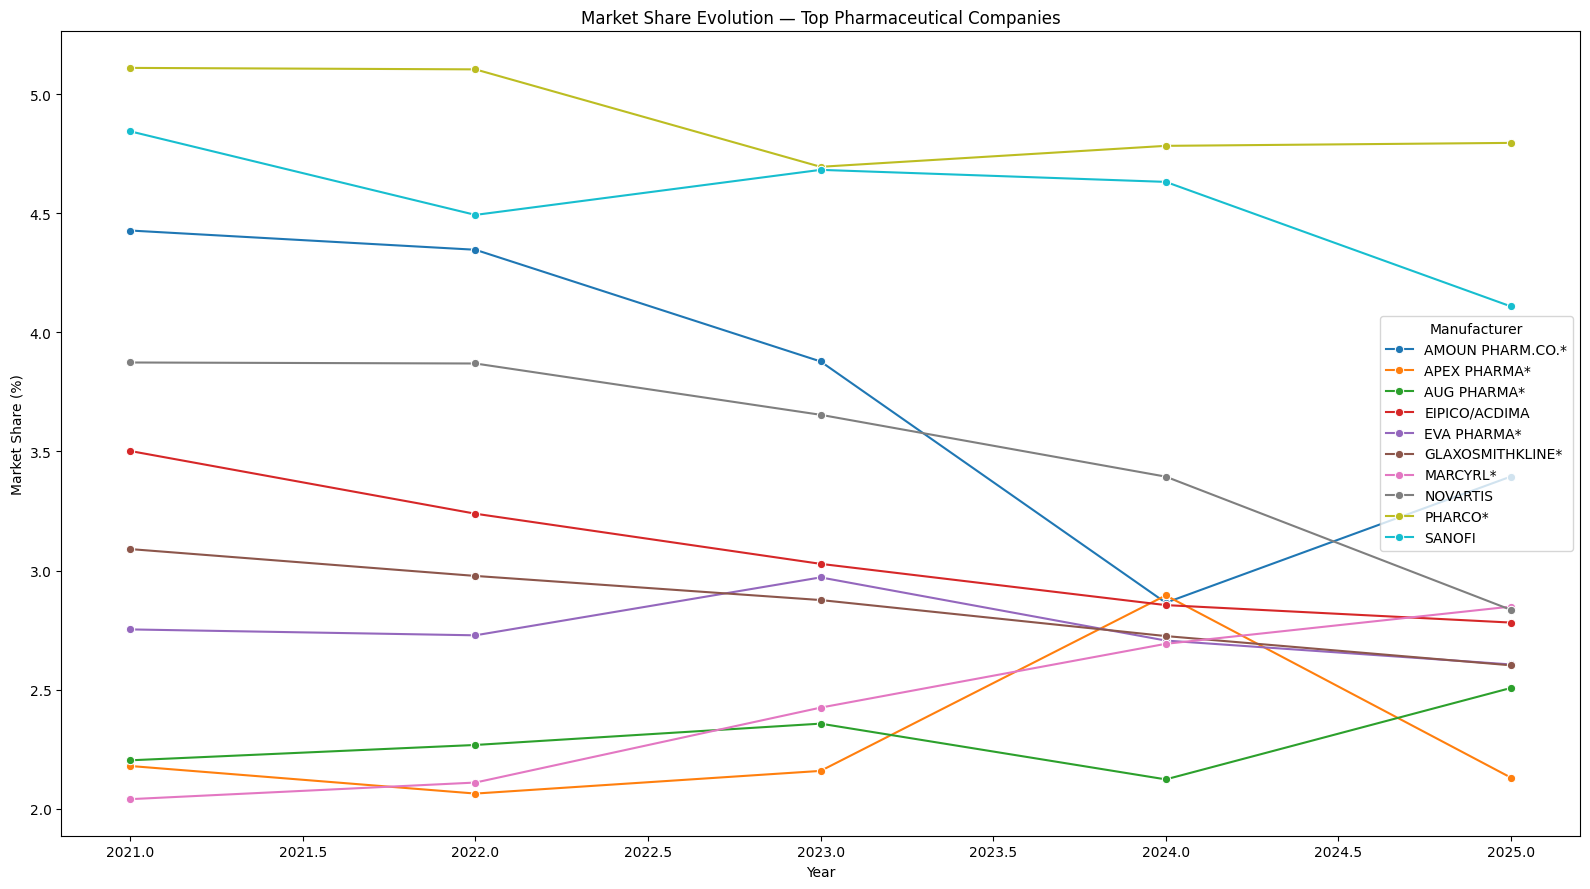

In [32]:
# ============================================================
# 29. MARKET SHARE TREND FOR TOP COMPANIES
# ============================================================

year_market = (
    df_company
    .groupby("Year")["Sales Value"]
    .sum()
    .reset_index(name="Total_Market_Sales")
)

company_share_trend = manufacturer_yearly.merge(
    year_market,
    on="Year",
    how="left"
)

company_share_trend["Market_Share_%"] = (
    company_share_trend["Sales_Value"]
    / company_share_trend["Total_Market_Sales"]
    * 100
)

company_share_top10 = company_share_trend[
    company_share_trend["Manufacturer"]
    .isin(top_companies)
]

plt.figure(figsize=(16, 9))

sns.lineplot(
    data=company_share_top10,
    x="Year",
    y="Market_Share_%",
    hue="Manufacturer",
    marker="o"
)

plt.title(
    "Market Share Evolution — Top Pharmaceutical Companies"
)

plt.xlabel("Year")
plt.ylabel("Market Share (%)")

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 30. COMPANY MARKET CONCENTRATION — HHI
# ============================================================

company_market_share = (
    manufacturer_sales["Market_Share_%"]
)

HHI_company = (
    company_market_share ** 2
).sum()

print(
    f"Company-level Market HHI: {HHI_company:,.2f}"
)

Company-level Market HHI: 177.79


In [34]:
# ============================================================
# 31. COMPANY CONCENTRATION INTERPRETATION
# ============================================================

if HHI_company < 1500:
    concentration_level = "Low Concentration"
elif HHI_company < 2500:
    concentration_level = "Moderate Concentration"
else:
    concentration_level = "High Concentration"

print(
    "Company Market Concentration:",
    concentration_level
)

Company Market Concentration: Low Concentration


In [35]:
# ============================================================
# 32. TOP 5 COMPANY MARKET SHARE
# ============================================================

top5_company_share = (
    manufacturer_sales
    .head(5)["Market_Share_%"]
    .sum()
)

top10_company_share = (
    manufacturer_sales
    .head(10)["Market_Share_%"]
    .sum()
)

print(
    f"Top 5 Company Market Share: {top5_company_share:.2f}%"
)

print(
    f"Top 10 Company Market Share: {top10_company_share:.2f}%"
)

Top 5 Company Market Share: 19.29%
Top 10 Company Market Share: 31.98%


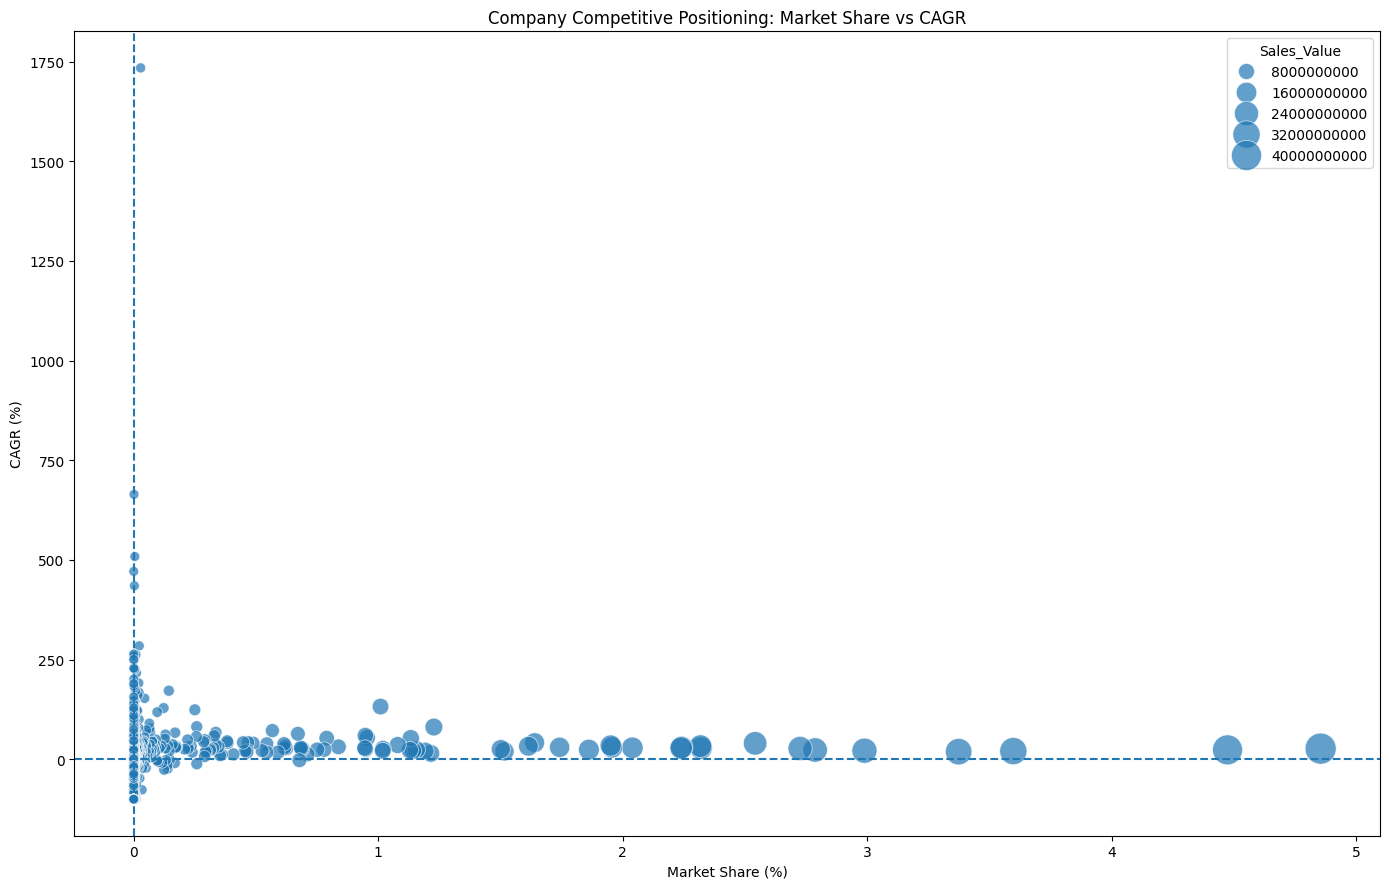

In [36]:
# ============================================================
# 33. COMPANY GROWTH VS MARKET SHARE
# ============================================================

growth_share = company_intelligence[
    [
        "Manufacturer",
        "Market_Share_%",
        "CAGR_%",
        "Sales_Value"
    ]
].copy()

growth_share = growth_share.dropna(
    subset=["CAGR_%"]
)

plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=growth_share,
    x="Market_Share_%",
    y="CAGR_%",
    size="Sales_Value",
    sizes=(50, 500),
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    growth_share["Market_Share_%"].median(),
    linestyle="--"
)

plt.title(
    "Company Competitive Positioning: Market Share vs CAGR"
)

plt.xlabel("Market Share (%)")
plt.ylabel("CAGR (%)")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# 34. COMPANY STRATEGIC QUADRANTS
# ============================================================

median_share = (
    growth_share["Market_Share_%"]
    .median()
)

median_growth = (
    growth_share["CAGR_%"]
    .median()
)

def assign_company_quadrant(row):

    if (
        row["Market_Share_%"] >= median_share
        and row["CAGR_%"] >= median_growth
    ):
        return "Market Leaders / Growth"

    elif (
        row["Market_Share_%"] >= median_share
        and row["CAGR_%"] < median_growth
    ):
        return "Market Leaders / Mature"

    elif (
        row["Market_Share_%"] < median_share
        and row["CAGR_%"] >= median_growth
    ):
        return "Growth Challengers"

    else:
        return "Small / Low Growth"


growth_share["Strategic_Quadrant"] = (
    growth_share.apply(
        assign_company_quadrant,
        axis=1
    )
)

display(
    growth_share
    .sort_values(
        "Sales_Value",
        ascending=False
    )
    .head(30)
)

,Manufacturer,Market_Share_%,CAGR_%,Sales_Value,Strategic_Quadrant
0,PHARCO*,4.855197,26.778554,4.286563e+10,Market Leaders / Growth
1,SANOFI,4.474263,23.616275,3.950244e+10,Market Leaders / Growth
2,AMOUN PHARM.CO.*,3.598065,20.533551,3.176665e+10,Market Leaders / Growth
3,NOVARTIS,3.374466,19.139160,2.979254e+10,Market Leaders / Growth
4,EIPICO/ACDIMA,2.989105,21.602265,2.639026e+10,Market Leaders / Growth
5,GLAXOSMITHKLINE*,2.787465,23.391065,2.461002e+10,Market Leaders / Growth
6,EVA PHARMA*,2.725896,27.053784,2.406643e+10,Market Leaders / Growth
7,MARCYRL*,2.541935,40.024885,2.244227e+10,Market Leaders / Growth
8,APEX PHARMA*,2.320118,28.079266,2.048389e+10,Market Leaders / Growth
9,AUG PHARMA*,2.318417,33.039853,2.046888e+10,Market Leaders / Growth


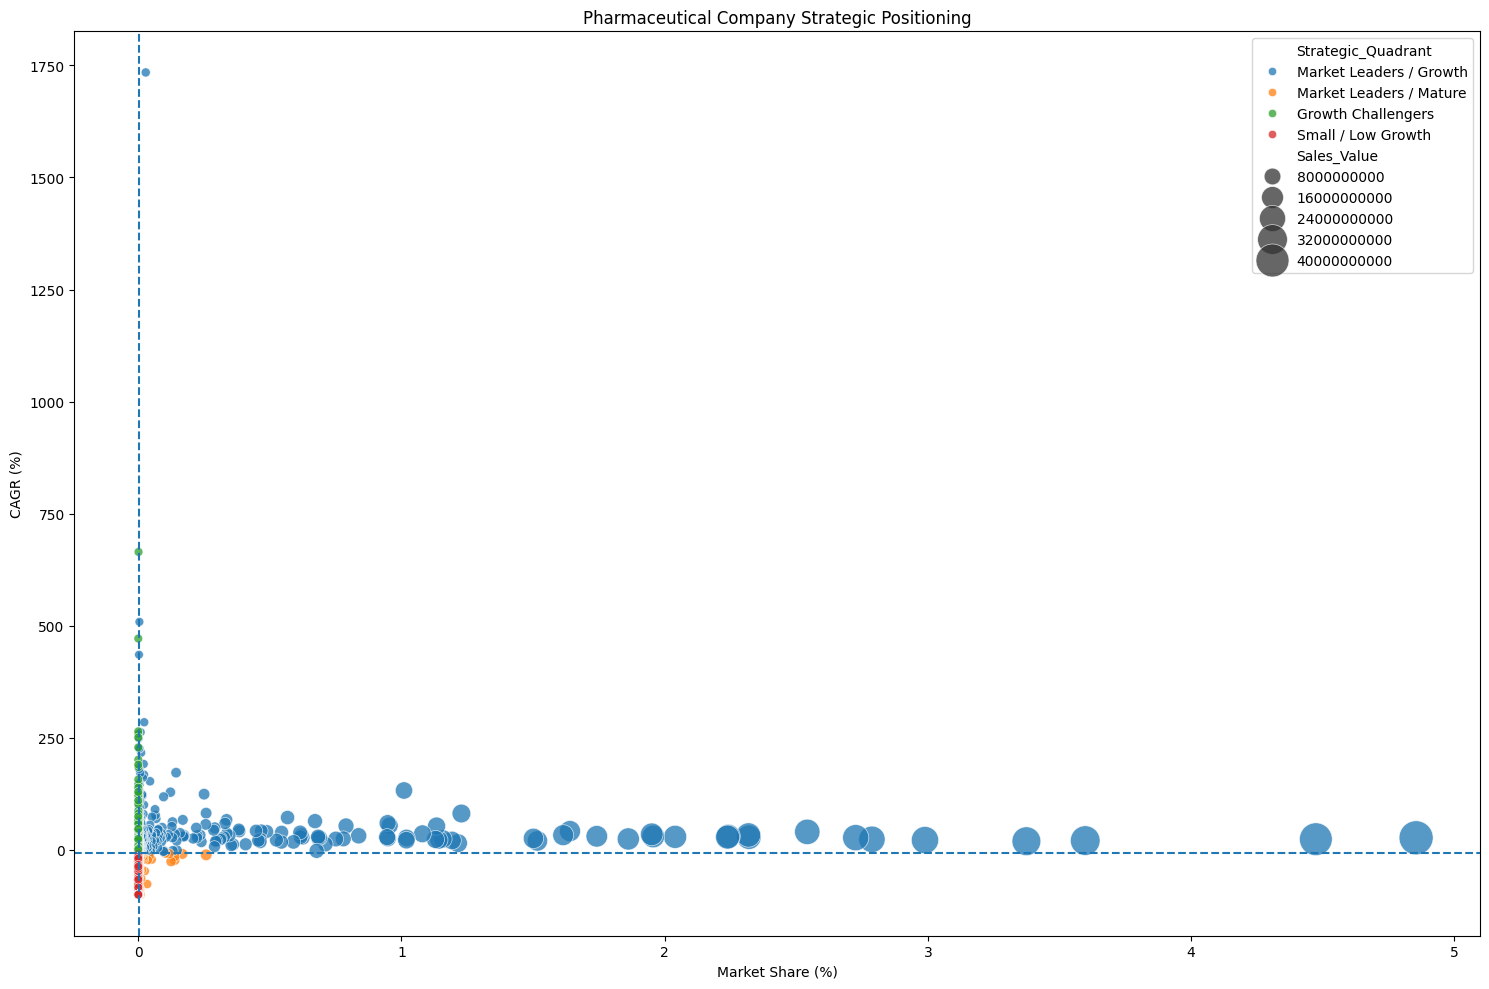

In [38]:
# ============================================================
# 35. COMPANY STRATEGIC QUADRANT VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 10))

sns.scatterplot(
    data=growth_share,
    x="Market_Share_%",
    y="CAGR_%",
    hue="Strategic_Quadrant",
    size="Sales_Value",
    sizes=(40, 600),
    alpha=0.75
)

plt.axhline(
    median_growth,
    linestyle="--"
)

plt.axvline(
    median_share,
    linestyle="--"
)

plt.title(
    "Pharmaceutical Company Strategic Positioning"
)

plt.xlabel("Market Share (%)")
plt.ylabel("CAGR (%)")

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# 36. NORMALIZED COMPANY PERFORMANCE SCORES
# ============================================================

score_columns = [
    "Sales_Value",
    "Market_Share_%",
    "CAGR_%",
    "Brand_Count",
    "Launch_Count",
    "Recent_Launches",
    "Sales_per_Brand"
]

company_scoring = company_intelligence.copy()

for col in score_columns:

    company_scoring[col] = (
        pd.to_numeric(
            company_scoring[col],
            errors="coerce"
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0)
    )

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(
    company_scoring[score_columns]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[
        f"{col}_Score"
        for col in score_columns
    ],
    index=company_scoring.index
)

company_scoring = pd.concat(
    [
        company_scoring,
        scaled_df
    ],
    axis=1
)

display(company_scoring.head())

,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,CAGR_%,Sales_per_Brand,Brand Name,Top_Brand_Sales,Top_Brand_Contribution_%,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%,Dominant_Channel,Dominant_Channel_Sales,Dominant_Channel_Share_%,Average_Selling_Price,Median_Selling_Price,Min_Selling_Price,Max_Selling_Price,Launch_Count,Recent_Launches,Sales_Value_Score,Market_Share_%_Score,CAGR_%_Score,Brand_Count_Score,Launch_Count_Score,Recent_Launches_Score,Sales_per_Brand_Score
0,PHARCO*,4.286563e+10,1.367007e+09,4.855197,310,164,60,2,26.778554,1.382762e+08,CLAVIMOX,2.931866e+09,6.839666,J01D2 CEPHALOSPORINS INJECT,3.386047e+09,7.899212,STORES,2.172784e+10,50.688258,63.407992,40.0,1.00,1800.00,310.0,28.0,1.000000,1.000000,0.069114,1.000000,1.000000,0.354430,0.150284
1,SANOFI,3.950244e+10,6.511505e+08,4.474263,97,78,41,2,23.616275,4.072417e+08,CLEXANE,5.555901e+09,14.064705,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705,PHARMACIES,2.794086e+10,70.731994,1212.634740,98.0,4.00,160000.00,96.0,12.0,0.921541,0.921541,0.067390,0.310680,0.309677,0.151899,0.442607
2,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065,127,109,36,2,20.533551,2.501311e+08,HIBIOTIC,5.093675e+09,16.034661,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290,PHARMACIES,2.309123e+10,72.690145,96.240481,51.0,4.00,5223.00,127.0,11.0,0.741075,0.741075,0.065710,0.407767,0.409677,0.139241,0.271853
3,NOVARTIS,2.979254e+10,3.468835e+08,3.374466,84,49,30,2,19.139160,3.546731e+08,CATAFLAM,3.536757e+09,11.871283,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024,PHARMACIES,2.846888e+10,95.557082,3701.833361,222.0,0.01,270501.71,82.0,1.0,0.695022,0.695022,0.064949,0.268608,0.264516,0.012658,0.385473
4,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105,186,112,45,2,21.602265,1.418831e+08,CEFOTAX,3.375660e+09,12.791312,J01D2 CEPHALOSPORINS INJECT,5.171401e+09,19.595871,PHARMACIES,2.011570e+10,76.223977,45.205502,30.0,1.50,6250.00,186.0,37.0,0.615651,0.615651,0.066292,0.598706,0.600000,0.468354,0.154204


In [40]:
# ============================================================
# 37. COMPANY INTELLIGENCE SCORE
# ============================================================

company_scoring["Company_Intelligence_Score"] = (
    company_scoring["Sales_Value_Score"] * 0.25
    + company_scoring["Market_Share_%_Score"] * 0.15
    + company_scoring["CAGR_%_Score"] * 0.20
    + company_scoring["Brand_Count_Score"] * 0.10
    + company_scoring["Launch_Count_Score"] * 0.10
    + company_scoring["Recent_Launches_Score"] * 0.10
    + company_scoring["Sales_per_Brand_Score"] * 0.10
)

company_scoring["Company_Intelligence_Score"] *= 100

company_scoring = company_scoring.sort_values(
    "Company_Intelligence_Score",
    ascending=False
)

display(
    company_scoring[
        [
            "Manufacturer",
            "Company_Intelligence_Score",
            "Sales_Value",
            "Market_Share_%",
            "CAGR_%",
            "Brand_Count",
            "Launch_Count"
        ]
    ].head(30)
)

,Manufacturer,Company_Intelligence_Score,Sales_Value,Market_Share_%,CAGR_%,Brand_Count,Launch_Count
0,PHARCO*,66.429426,4.286563e+10,4.855197,26.778554,310,310.0
1,SANOFI,50.358066,3.950244e+10,4.474263,23.616275,97,96.0
4,EIPICO/ACDIMA,44.164513,2.639026e+10,2.989105,21.602265,186,186.0
2,AMOUN PHARM.CO.*,43.242568,3.176665e+10,3.598065,20.533551,127,127.0
6,EVA PHARMA*,41.944789,2.406643e+10,2.725896,27.053784,173,173.0
3,NOVARTIS,38.412407,2.979254e+10,3.374466,19.139160,84,82.0
7,MARCYRL*,38.106213,2.244227e+10,2.541935,40.024885,167,167.0
11,HIKMA PLC*,34.142583,1.976784e+10,2.239014,28.356721,153,153.0
5,GLAXOSMITHKLINE*,33.674618,2.461002e+10,2.787465,23.391065,96,89.0
15,GLOBAL NAPI*,32.340602,1.643821e+10,1.861881,24.205789,176,176.0


In [41]:
# ============================================================
# 38. COMPANY STRATEGIC CLASSIFICATION
# ============================================================

score_q75 = (
    company_scoring[
        "Company_Intelligence_Score"
    ].quantile(0.75)
)

score_q50 = (
    company_scoring[
        "Company_Intelligence_Score"
    ].quantile(0.50)
)

score_q25 = (
    company_scoring[
        "Company_Intelligence_Score"
    ].quantile(0.25)
)


def classify_company(score):

    if score >= score_q75:
        return "Strategic Leader"

    elif score >= score_q50:
        return "Strong Competitor"

    elif score >= score_q25:
        return "Emerging / Monitor"

    else:
        return "Low Strategic Priority"


company_scoring["Company_Strategic_Class"] = (
    company_scoring[
        "Company_Intelligence_Score"
    ].apply(classify_company)
)

display(
    company_scoring[
        [
            "Manufacturer",
            "Company_Intelligence_Score",
            "Company_Strategic_Class"
        ]
    ].head(30)
)

,Manufacturer,Company_Intelligence_Score,Company_Strategic_Class
0,PHARCO*,66.429426,Strategic Leader
1,SANOFI,50.358066,Strategic Leader
4,EIPICO/ACDIMA,44.164513,Strategic Leader
2,AMOUN PHARM.CO.*,43.242568,Strategic Leader
6,EVA PHARMA*,41.944789,Strategic Leader
3,NOVARTIS,38.412407,Strategic Leader
7,MARCYRL*,38.106213,Strategic Leader
11,HIKMA PLC*,34.142583,Strategic Leader
5,GLAXOSMITHKLINE*,33.674618,Strategic Leader
15,GLOBAL NAPI*,32.340602,Strategic Leader


In [42]:
# ============================================================
# 39. COMPANY STRATEGIC ACTION
# ============================================================

def company_action(row):

    if row["Company_Strategic_Class"] == "Strategic Leader":

        if row["CAGR_%"] >= 0:
            return "Defend & Expand"

        return "Defend & Optimize"

    elif row["Company_Strategic_Class"] == "Strong Competitor":

        if row["CAGR_%"] > 0:
            return "Accelerate Growth"

        return "Improve Portfolio"

    elif row["Company_Strategic_Class"] == "Emerging / Monitor":

        if row["CAGR_%"] > 0:
            return "Validate & Scale"

        return "Monitor"

    else:

        return "Selective Investment / Deprioritize"


company_scoring["Strategic_Action"] = (
    company_scoring.apply(
        company_action,
        axis=1
    )
)

display(
    company_scoring[
        [
            "Manufacturer",
            "Company_Strategic_Class",
            "Strategic_Action"
        ]
    ].head(30)
)

,Manufacturer,Company_Strategic_Class,Strategic_Action
0,PHARCO*,Strategic Leader,Defend & Expand
1,SANOFI,Strategic Leader,Defend & Expand
4,EIPICO/ACDIMA,Strategic Leader,Defend & Expand
2,AMOUN PHARM.CO.*,Strategic Leader,Defend & Expand
6,EVA PHARMA*,Strategic Leader,Defend & Expand
3,NOVARTIS,Strategic Leader,Defend & Expand
7,MARCYRL*,Strategic Leader,Defend & Expand
11,HIKMA PLC*,Strategic Leader,Defend & Expand
5,GLAXOSMITHKLINE*,Strategic Leader,Defend & Expand
15,GLOBAL NAPI*,Strategic Leader,Defend & Expand


In [43]:
# ============================================================
# 40. COMPANY RANKING
# ============================================================

company_scoring["Company_Rank"] = (
    company_scoring[
        "Company_Intelligence_Score"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

company_scoring = company_scoring.sort_values(
    "Company_Rank"
)

display(
    company_scoring[
        [
            "Company_Rank",
            "Manufacturer",
            "Company_Intelligence_Score",
            "Company_Strategic_Class",
            "Strategic_Action"
        ]
    ].head(30)
)

,Company_Rank,Manufacturer,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action
0,1,PHARCO*,66.429426,Strategic Leader,Defend & Expand
1,2,SANOFI,50.358066,Strategic Leader,Defend & Expand
4,3,EIPICO/ACDIMA,44.164513,Strategic Leader,Defend & Expand
2,4,AMOUN PHARM.CO.*,43.242568,Strategic Leader,Defend & Expand
6,5,EVA PHARMA*,41.944789,Strategic Leader,Defend & Expand
3,6,NOVARTIS,38.412407,Strategic Leader,Defend & Expand
7,7,MARCYRL*,38.106213,Strategic Leader,Defend & Expand
11,8,HIKMA PLC*,34.142583,Strategic Leader,Defend & Expand
5,9,GLAXOSMITHKLINE*,33.674618,Strategic Leader,Defend & Expand
15,10,GLOBAL NAPI*,32.340602,Strategic Leader,Defend & Expand


In [44]:
# ============================================================
# 41. TOP 20 COMPANY INTELLIGENCE
# ============================================================

top20_company_intelligence = (
    company_scoring
    .head(20)
    .copy()
)

display(top20_company_intelligence)

,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,CAGR_%,Sales_per_Brand,Brand Name,Top_Brand_Sales,Top_Brand_Contribution_%,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%,Dominant_Channel,Dominant_Channel_Sales,Dominant_Channel_Share_%,Average_Selling_Price,Median_Selling_Price,Min_Selling_Price,Max_Selling_Price,Launch_Count,Recent_Launches,Sales_Value_Score,Market_Share_%_Score,CAGR_%_Score,Brand_Count_Score,Launch_Count_Score,Recent_Launches_Score,Sales_per_Brand_Score,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action,Company_Rank
0,PHARCO*,4.286563e+10,1.367007e+09,4.855197,310,164,60,2,26.778554,1.382762e+08,CLAVIMOX,2.931866e+09,6.839666,J01D2 CEPHALOSPORINS INJECT,3.386047e+09,7.899212,STORES,2.172784e+10,50.688258,63.407992,40.0,1.00,1800.00,310.0,28.0,1.000000,1.000000,0.069114,1.000000,1.000000,0.354430,0.150284,66.429426,Strategic Leader,Defend & Expand,1
1,SANOFI,3.950244e+10,6.511505e+08,4.474263,97,78,41,2,23.616275,4.072417e+08,CLEXANE,5.555901e+09,14.064705,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705,PHARMACIES,2.794086e+10,70.731994,1212.634740,98.0,4.00,160000.00,96.0,12.0,0.921541,0.921541,0.067390,0.310680,0.309677,0.151899,0.442607,50.358066,Strategic Leader,Defend & Expand,2
4,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105,186,112,45,2,21.602265,1.418831e+08,CEFOTAX,3.375660e+09,12.791312,J01D2 CEPHALOSPORINS INJECT,5.171401e+09,19.595871,PHARMACIES,2.011570e+10,76.223977,45.205502,30.0,1.50,6250.00,186.0,37.0,0.615651,0.615651,0.066292,0.598706,0.600000,0.468354,0.154204,44.164513,Strategic Leader,Defend & Expand,3
2,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065,127,109,36,2,20.533551,2.501311e+08,HIBIOTIC,5.093675e+09,16.034661,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290,PHARMACIES,2.309123e+10,72.690145,96.240481,51.0,4.00,5223.00,127.0,11.0,0.741075,0.741075,0.065710,0.407767,0.409677,0.139241,0.271853,43.242568,Strategic Leader,Defend & Expand,4
6,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896,173,112,37,2,27.053784,1.391123e+08,CONVENTIN,4.798667e+09,19.939254,N02D0 GABAPENTINOID PRODUCTS,5.055669e+09,21.007139,PHARMACIES,1.745321e+10,72.520984,258.894466,113.5,5.75,64920.00,173.0,43.0,0.561439,0.561439,0.069264,0.556634,0.558065,0.544304,0.151193,41.944789,Strategic Leader,Defend & Expand,5
3,NOVARTIS,2.979254e+10,3.468835e+08,3.374466,84,49,30,2,19.139160,3.546731e+08,CATAFLAM,3.536757e+09,11.871283,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024,PHARMACIES,2.846888e+10,95.557082,3701.833361,222.0,0.01,270501.71,82.0,1.0,0.695022,0.695022,0.064949,0.268608,0.264516,0.012658,0.385473,38.412407,Strategic Leader,Defend & Expand,6
7,MARCYRL*,2.244227e+10,2.892759e+08,2.541935,167,107,38,2,40.024885,1.343849e+08,NEVILOB,1.966239e+09,8.761321,C10C0 LIP.REG.CO.W.OTH.LIP.REG,2.852656e+09,12.711083,PHARMACIES,1.597698e+10,71.191465,167.044150,88.0,2.50,23000.00,167.0,27.0,0.523549,0.523549,0.076335,0.537217,0.538710,0.341772,0.146055,38.106213,Strategic Leader,Defend & Expand,7
11,HIKMA PLC*,1.976784e+10,4.324577e+08,2.239014,153,105,38,2,28.356721,1.292016e+08,MEGAMOX,2.670747e+09,13.510567,J01D1 CEPHALOSPORINS ORAL,2.874825e+09,14.542941,PHARMACIES,1.472231e+10,74.476090,518.564461,120.0,3.00,27786.00,153.0,24.0,0.461158,0.461158,0.069974,0.491909,0.493548,0.303797,0.140421,34.142583,Strategic Leader,Defend & Expand,8
5,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465,96,68,39,2,23.391065,2.563543e+08,AUGMENTIN,6.813283e+09,27.684999,J01C1 BROAD SPECT PENICILL ORAL,6.813630e+09,27.686413,PHARMACIES,1.576259e+10,64.049482,472.620601,81.0,4.20,160000.00,89.0,5.0,0.574120,0.574120,0.067267,0.307443,0.287097,0.063291,0.278616,33.674618,Strategic Leader,Defend & Expand,9
15,GLOBAL NAPI*,1.643821e+10,3.268715e+08,1.861881,176,107,38,2,24.205789,9.339890e+07,AMBEZIM-G,1.936857e+09,11.782653,V03H0 ANTI-INFLAMMATORY ENZYME,1.936857e+09,11.782653,PHARMAC

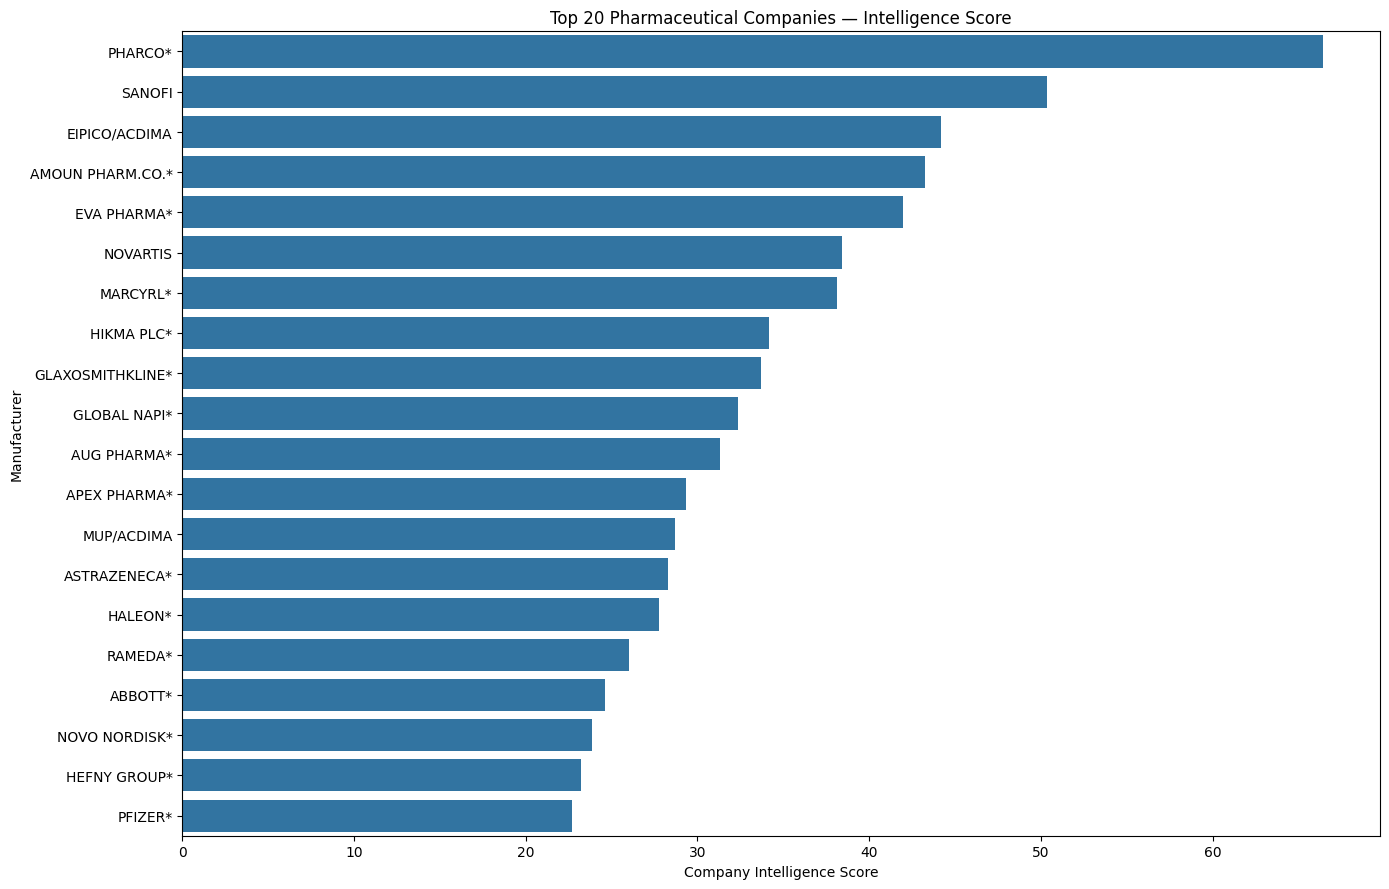

In [45]:
# ============================================================
# 42. COMPANY SCORE VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 9))

sns.barplot(
    data=top20_company_intelligence,
    y="Manufacturer",
    x="Company_Intelligence_Score"
)

plt.title(
    "Top 20 Pharmaceutical Companies — Intelligence Score"
)

plt.xlabel("Company Intelligence Score")
plt.ylabel("Manufacturer")

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# 43. STRATEGIC CLASS DISTRIBUTION
# ============================================================

strategic_class_distribution = (
    company_scoring[
        "Company_Strategic_Class"
    ]
    .value_counts()
    .reset_index()
)

strategic_class_distribution.columns = [
    "Strategic_Class",
    "Company_Count"
]

display(strategic_class_distribution)

,Strategic_Class,Company_Count
0,Strategic Leader,349
1,Strong Competitor,349
2,Emerging / Monitor,349
3,Low Strategic Priority,349


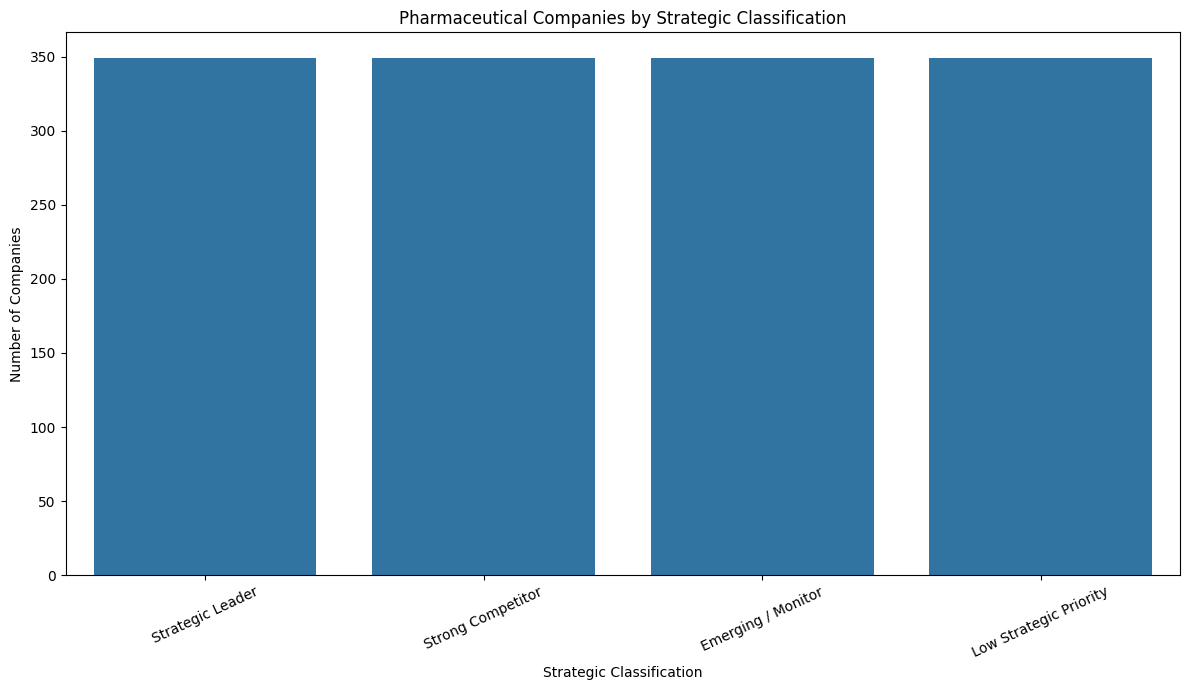

In [47]:
# ============================================================
# 44. STRATEGIC CLASS VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=strategic_class_distribution,
    x="Strategic_Class",
    y="Company_Count"
)

plt.title(
    "Pharmaceutical Companies by Strategic Classification"
)

plt.xlabel("Strategic Classification")
plt.ylabel("Number of Companies")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# 45. STRATEGIC ACTION DISTRIBUTION
# ============================================================

action_distribution = (
    company_scoring[
        "Strategic_Action"
    ]
    .value_counts()
    .reset_index()
)

action_distribution.columns = [
    "Strategic_Action",
    "Company_Count"
]

display(action_distribution)

,Strategic_Action,Company_Count
0,Selective Investment / Deprioritize,349
1,Monitor,338
2,Defend & Expand,322
3,Improve Portfolio,294
4,Accelerate Growth,55
5,Defend & Optimize,27
6,Validate & Scale,11


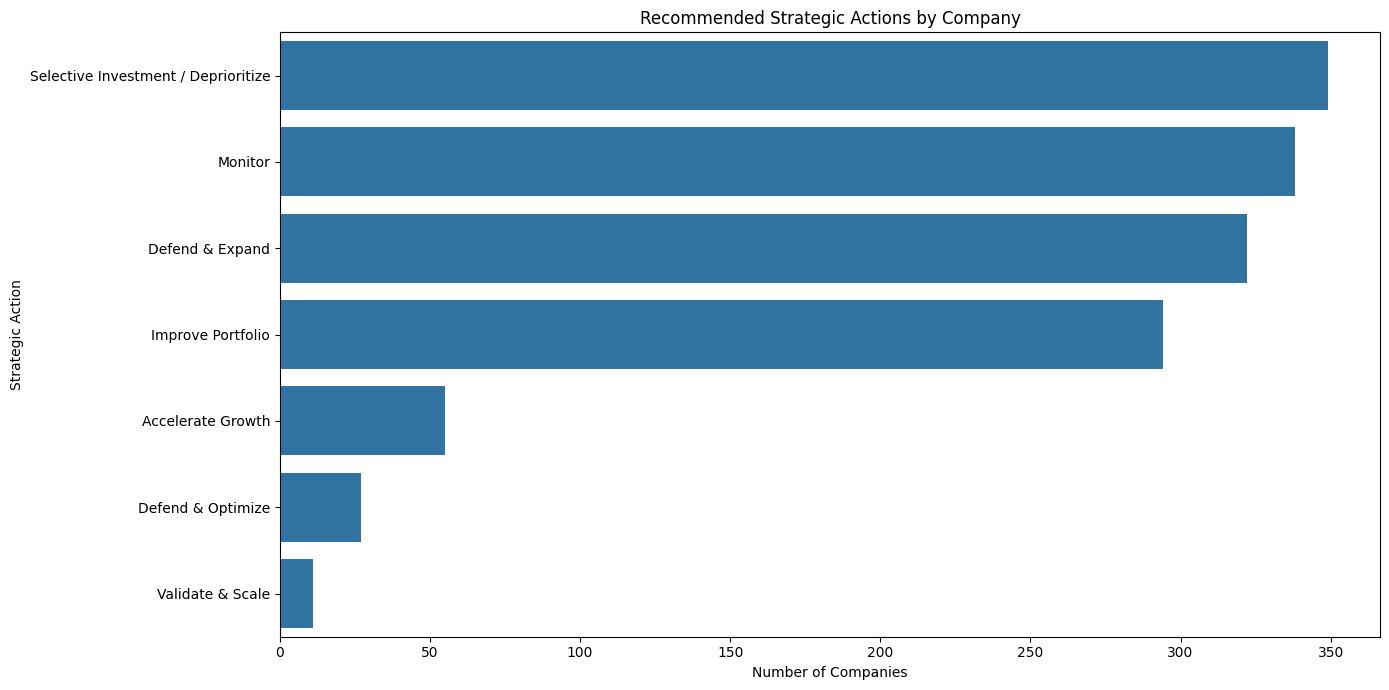

In [49]:
# ============================================================
# 46. STRATEGIC ACTION VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=action_distribution,
    x="Company_Count",
    y="Strategic_Action"
)

plt.title(
    "Recommended Strategic Actions by Company"
)

plt.xlabel("Number of Companies")
plt.ylabel("Strategic Action")

plt.tight_layout()
plt.show()

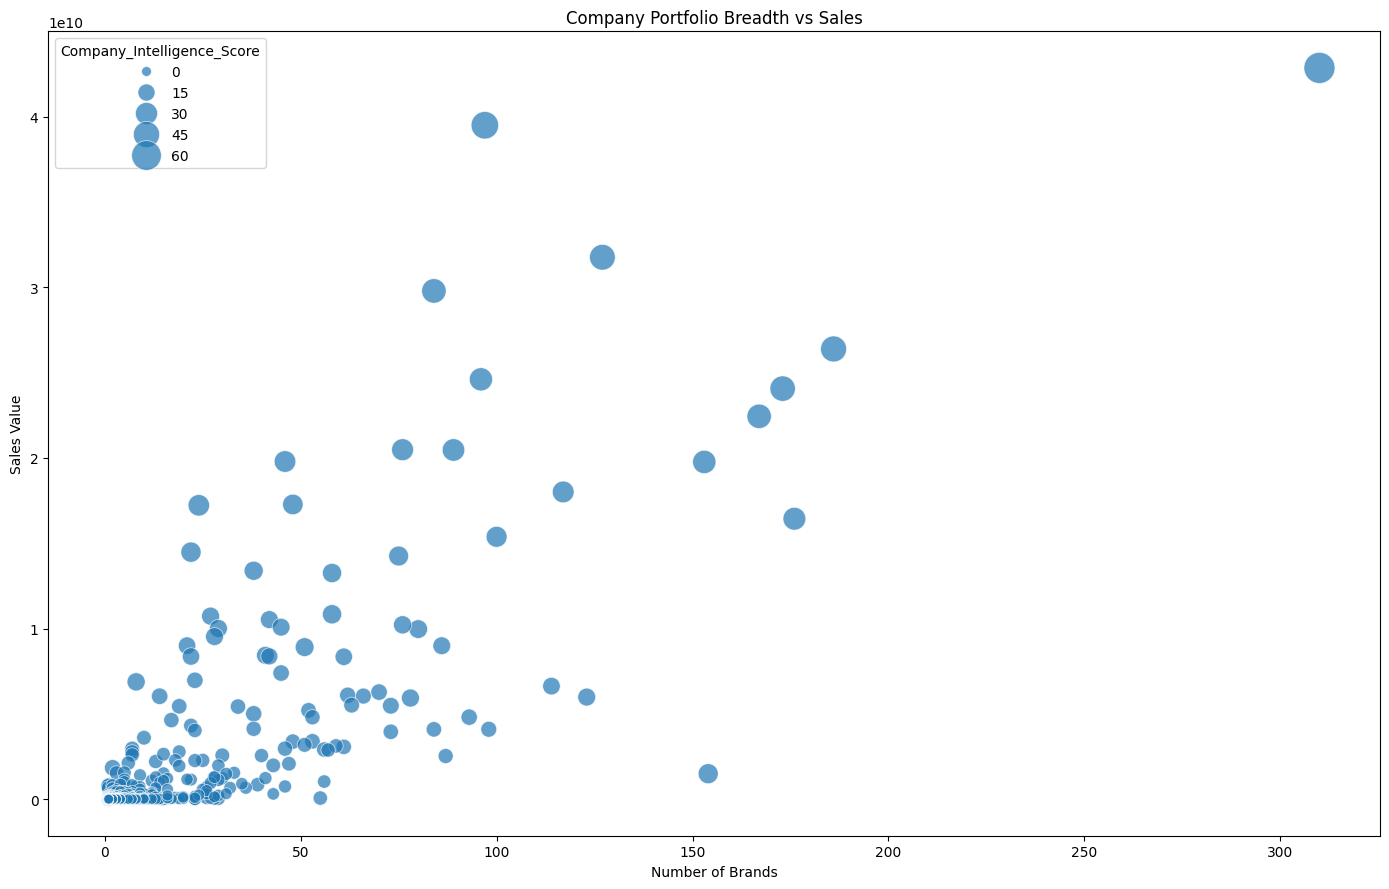

In [50]:
# ============================================================
# 47. COMPANY PORTFOLIO SIZE VS SALES
# ============================================================

plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=company_scoring,
    x="Brand_Count",
    y="Sales_Value",
    size="Company_Intelligence_Score",
    sizes=(50, 500),
    alpha=0.7
)

plt.title(
    "Company Portfolio Breadth vs Sales"
)

plt.xlabel("Number of Brands")
plt.ylabel("Sales Value")

plt.tight_layout()
plt.show()

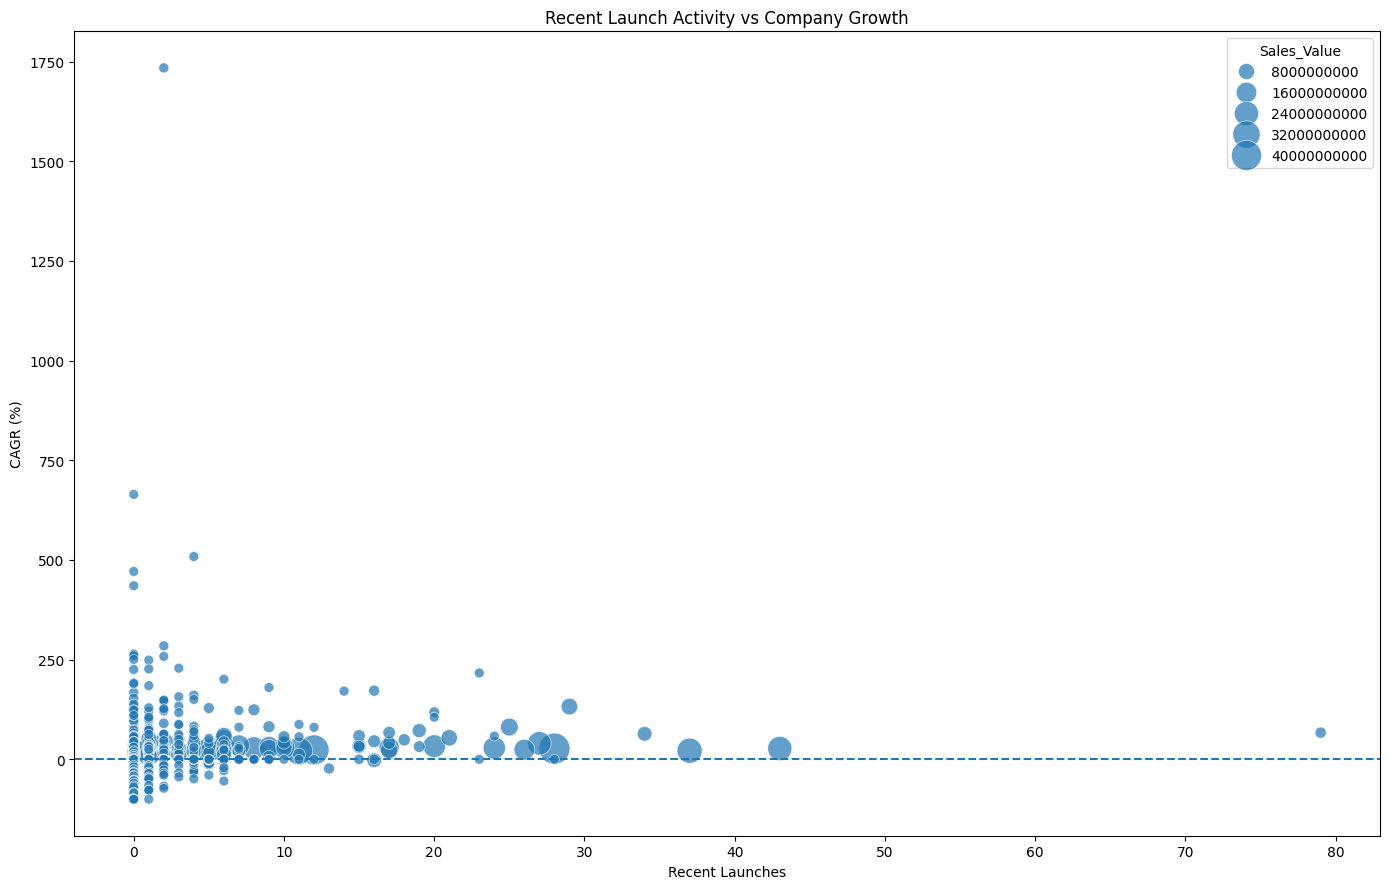

In [51]:
# ============================================================
# 48. COMPANY LAUNCH ACTIVITY VS GROWTH
# ============================================================

plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=company_scoring,
    x="Recent_Launches",
    y="CAGR_%",
    size="Sales_Value",
    sizes=(50, 500),
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Recent Launch Activity vs Company Growth"
)

plt.xlabel("Recent Launches")
plt.ylabel("CAGR (%)")

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# 49. COMPANY BRAND DEPENDENCY
# ============================================================

company_scoring["Portfolio_Dependence_%"] = (
    company_scoring[
        "Top_Brand_Contribution_%"
    ]
)

def portfolio_risk(value):

    if value >= 70:
        return "High Dependency"

    elif value >= 50:
        return "Moderate Dependency"

    else:
        return "Diversified Portfolio"


company_scoring["Portfolio_Dependence_Risk"] = (
    company_scoring[
        "Portfolio_Dependence_%"
    ].apply(portfolio_risk)
)

display(
    company_scoring[
        [
            "Manufacturer",
            "Brand_Count",
            "Top_Brand_Contribution_%",
            "Portfolio_Dependence_Risk"
        ]
    ]
    .sort_values(
        "Top_Brand_Contribution_%",
        ascending=False
    )
    .head(30)
)

,Manufacturer,Brand_Count,Top_Brand_Contribution_%,Portfolio_Dependence_Risk
1395,BOFORS*,1,100.0,High Dependency
1060,MTD INT L SA*,1,100.0,High Dependency
1206,TALANT PHARMA*,1,100.0,High Dependency
1205,ATLANTIC GROUP*,1,100.0,High Dependency
1203,ICON PHARMA*,1,100.0,High Dependency
438,CSPC*,1,100.0,High Dependency
1202,ASTRAMEDICA,1,100.0,High Dependency
328,CORYNE,1,100.0,High Dependency
1201,PHARMAKO INT.*,1,100.0,High Dependency
1200,CAPSTONE PHARMA*,1,100.0,High Dependency


In [53]:
# ============================================================
# 50. COMPANY FINAL INTELLIGENCE TABLE
# ============================================================

company_final = company_scoring[
    [
        "Company_Rank",
        "Manufacturer",
        "Sales_Value",
        "Sales_Units",
        "Market_Share_%",
        "CAGR_%",
        "Brand_Count",
        "Therapeutic_Class_Count",
        "Market_Category_Count",
        "Distribution_Channel_Count",
        "Sales_per_Brand",
        "Top_Brand_Sales",
        "Top_Brand_Contribution_%",
        "Top_Therapeutic_Class",
        "Top_Therapeutic_Sales",
        "Top_Therapeutic_Share_%",
        "Dominant_Channel",
        "Dominant_Channel_Sales",
        "Dominant_Channel_Share_%",
        "Average_Selling_Price",
        "Median_Selling_Price",
        "Launch_Count",
        "Recent_Launches",
        "Company_Intelligence_Score",
        "Company_Strategic_Class",
        "Strategic_Action",
        "Portfolio_Dependence_Risk"
    ]
].copy()

company_final = company_final.sort_values(
    "Company_Rank"
)

display(company_final.head(30))

,Company_Rank,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,CAGR_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,Sales_per_Brand,Top_Brand_Sales,Top_Brand_Contribution_%,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%,Dominant_Channel,Dominant_Channel_Sales,Dominant_Channel_Share_%,Average_Selling_Price,Median_Selling_Price,Launch_Count,Recent_Launches,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action,Portfolio_Dependence_Risk
0,1,PHARCO*,4.286563e+10,1.367007e+09,4.855197,26.778554,310,164,60,2,1.382762e+08,2.931866e+09,6.839666,J01D2 CEPHALOSPORINS INJECT,3.386047e+09,7.899212,STORES,2.172784e+10,50.688258,63.407992,40.0,310.0,28.0,66.429426,Strategic Leader,Defend & Expand,Diversified Portfolio
1,2,SANOFI,3.950244e+10,6.511505e+08,4.474263,23.616275,97,78,41,2,4.072417e+08,5.555901e+09,14.064705,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705,PHARMACIES,2.794086e+10,70.731994,1212.634740,98.0,96.0,12.0,50.358066,Strategic Leader,Defend & Expand,Diversified Portfolio
4,3,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105,21.602265,186,112,45,2,1.418831e+08,3.375660e+09,12.791312,J01D2 CEPHALOSPORINS INJECT,5.171401e+09,19.595871,PHARMACIES,2.011570e+10,76.223977,45.205502,30.0,186.0,37.0,44.164513,Strategic Leader,Defend & Expand,Diversified Portfolio
2,4,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065,20.533551,127,109,36,2,2.501311e+08,5.093675e+09,16.034661,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290,PHARMACIES,2.309123e+10,72.690145,96.240481,51.0,127.0,11.0,43.242568,Strategic Leader,Defend & Expand,Diversified Portfolio
6,5,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896,27.053784,173,112,37,2,1.391123e+08,4.798667e+09,19.939254,N02D0 GABAPENTINOID PRODUCTS,5.055669e+09,21.007139,PHARMACIES,1.745321e+10,72.520984,258.894466,113.5,173.0,43.0,41.944789,Strategic Leader,Defend & Expand,Diversified Portfolio
3,6,NOVARTIS,2.979254e+10,3.468835e+08,3.374466,19.139160,84,49,30,2,3.546731e+08,3.536757e+09,11.871283,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024,PHARMACIES,2.846888e+10,95.557082,3701.833361,222.0,82.0,1.0,38.412407,Strategic Leader,Defend & Expand,Diversified Portfolio
7,7,MARCYRL*,2.244227e+10,2.892759e+08,2.541935,40.024885,167,107,38,2,1.343849e+08,1.966239e+09,8.761321,C10C0 LIP.REG.CO.W.OTH.LIP.REG,2.852656e+09,12.711083,PHARMACIES,1.597698e+10,71.191465,167.044150,88.0,167.0,27.0,38.106213,Strategic Leader,Defend & Expand,Diversified Portfolio
11,8,HIKMA PLC*,1.976784e+10,4.324577e+08,2.239014,28.356721,153,105,38,2,1.292016e+08,2.670747e+09,13.510567,J01D1 CEPHALOSPORINS ORAL,2.874825e+09,14.542941,PHARMACIES,1.472231e+10,74.476090,518.564461,120.0,153.0,24.0,34.142583,Strategic Leader,Defend & Expand,Diversified Portfolio
5,9,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465,23.391065,96,68,39,2,2.563543e+08,6.813283e+09,27.684999,J01C1 BROAD SPECT PENICILL ORAL,6.813630e+09,27.686413,PHARMACIES,1.576259e+10,64.049482,472.620601,81.0,89.0,5.0,33.674618,Strategic Leader,Defend & Expand,Diversified Portfolio
15,10,GLOBAL NAPI*,1.643821e+10,3.268715e+08,1.861881,24.205789,176,107,38,2,9.339890e+07,1.936857e+09,11.782653,V03H0 ANTI-INFLAMMATORY ENZYME,1.936857e+09,11.782653,PHARMACIES,1.194453e+10,72.663247,112.000112,65.0,176.0,26.0,32.340602,Strategic Leader,Defend & Expand,Diversified Portfolio


In [54]:
# ============================================================
# 51. EXECUTIVE TOP 20 TABLE
# ============================================================

executive_company_table = company_final.head(20).copy()

display(
    executive_company_table[
        [
            "Company_Rank",
            "Manufacturer",
            "Sales_Value",
            "Market_Share_%",
            "CAGR_%",
            "Brand_Count",
            "Launch_Count",
            "Recent_Launches",
            "Company_Intelligence_Score",
            "Company_Strategic_Class",
            "Strategic_Action"
        ]
    ]
)

,Company_Rank,Manufacturer,Sales_Value,Market_Share_%,CAGR_%,Brand_Count,Launch_Count,Recent_Launches,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action
0,1,PHARCO*,4.286563e+10,4.855197,26.778554,310,310.0,28.0,66.429426,Strategic Leader,Defend & Expand
1,2,SANOFI,3.950244e+10,4.474263,23.616275,97,96.0,12.0,50.358066,Strategic Leader,Defend & Expand
4,3,EIPICO/ACDIMA,2.639026e+10,2.989105,21.602265,186,186.0,37.0,44.164513,Strategic Leader,Defend & Expand
2,4,AMOUN PHARM.CO.*,3.176665e+10,3.598065,20.533551,127,127.0,11.0,43.242568,Strategic Leader,Defend & Expand
6,5,EVA PHARMA*,2.406643e+10,2.725896,27.053784,173,173.0,43.0,41.944789,Strategic Leader,Defend & Expand
3,6,NOVARTIS,2.979254e+10,3.374466,19.139160,84,82.0,1.0,38.412407,Strategic Leader,Defend & Expand
7,7,MARCYRL*,2.244227e+10,2.541935,40.024885,167,167.0,27.0,38.106213,Strategic Leader,Defend & Expand
11,8,HIKMA PLC*,1.976784e+10,2.239014,28.356721,153,153.0,24.0,34.142583,Strategic Leader,Defend & Expand
5,9,GLAXOSMITHKLINE*,2.461002e+10,2.787465,23.391065,96,89.0,5.0,33.674618,Strategic Leader,Defend & Expand
15,10,GLOBAL NAPI*,1.643821e+10,1.861881,24.205789,176,176.0,26.0,32.340602,Strategic Leader,Defend & Expand


In [55]:
# ============================================================
# 52. COMPANY LEADERS
# ============================================================

company_leaders = company_final[
    company_final[
        "Company_Strategic_Class"
    ] == "Strategic Leader"
].copy()

display(company_leaders.head(20))

,Company_Rank,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,CAGR_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,Sales_per_Brand,Top_Brand_Sales,Top_Brand_Contribution_%,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%,Dominant_Channel,Dominant_Channel_Sales,Dominant_Channel_Share_%,Average_Selling_Price,Median_Selling_Price,Launch_Count,Recent_Launches,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action,Portfolio_Dependence_Risk
0,1,PHARCO*,4.286563e+10,1.367007e+09,4.855197,26.778554,310,164,60,2,1.382762e+08,2.931866e+09,6.839666,J01D2 CEPHALOSPORINS INJECT,3.386047e+09,7.899212,STORES,2.172784e+10,50.688258,63.407992,40.0,310.0,28.0,66.429426,Strategic Leader,Defend & Expand,Diversified Portfolio
1,2,SANOFI,3.950244e+10,6.511505e+08,4.474263,23.616275,97,78,41,2,4.072417e+08,5.555901e+09,14.064705,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705,PHARMACIES,2.794086e+10,70.731994,1212.634740,98.0,96.0,12.0,50.358066,Strategic Leader,Defend & Expand,Diversified Portfolio
4,3,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105,21.602265,186,112,45,2,1.418831e+08,3.375660e+09,12.791312,J01D2 CEPHALOSPORINS INJECT,5.171401e+09,19.595871,PHARMACIES,2.011570e+10,76.223977,45.205502,30.0,186.0,37.0,44.164513,Strategic Leader,Defend & Expand,Diversified Portfolio
2,4,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065,20.533551,127,109,36,2,2.501311e+08,5.093675e+09,16.034661,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290,PHARMACIES,2.309123e+10,72.690145,96.240481,51.0,127.0,11.0,43.242568,Strategic Leader,Defend & Expand,Diversified Portfolio
6,5,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896,27.053784,173,112,37,2,1.391123e+08,4.798667e+09,19.939254,N02D0 GABAPENTINOID PRODUCTS,5.055669e+09,21.007139,PHARMACIES,1.745321e+10,72.520984,258.894466,113.5,173.0,43.0,41.944789,Strategic Leader,Defend & Expand,Diversified Portfolio
3,6,NOVARTIS,2.979254e+10,3.468835e+08,3.374466,19.139160,84,49,30,2,3.546731e+08,3.536757e+09,11.871283,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024,PHARMACIES,2.846888e+10,95.557082,3701.833361,222.0,82.0,1.0,38.412407,Strategic Leader,Defend & Expand,Diversified Portfolio
7,7,MARCYRL*,2.244227e+10,2.892759e+08,2.541935,40.024885,167,107,38,2,1.343849e+08,1.966239e+09,8.761321,C10C0 LIP.REG.CO.W.OTH.LIP.REG,2.852656e+09,12.711083,PHARMACIES,1.597698e+10,71.191465,167.044150,88.0,167.0,27.0,38.106213,Strategic Leader,Defend & Expand,Diversified Portfolio
11,8,HIKMA PLC*,1.976784e+10,4.324577e+08,2.239014,28.356721,153,105,38,2,1.292016e+08,2.670747e+09,13.510567,J01D1 CEPHALOSPORINS ORAL,2.874825e+09,14.542941,PHARMACIES,1.472231e+10,74.476090,518.564461,120.0,153.0,24.0,34.142583,Strategic Leader,Defend & Expand,Diversified Portfolio
5,9,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465,23.391065,96,68,39,2,2.563543e+08,6.813283e+09,27.684999,J01C1 BROAD SPECT PENICILL ORAL,6.813630e+09,27.686413,PHARMACIES,1.576259e+10,64.049482,472.620601,81.0,89.0,5.0,33.674618,Strategic Leader,Defend & Expand,Diversified Portfolio
15,10,GLOBAL NAPI*,1.643821e+10,3.268715e+08,1.861881,24.205789,176,107,38,2,9.339890e+07,1.936857e+09,11.782653,V03H0 ANTI-INFLAMMATORY ENZYME,1.936857e+09,11.782653,PHARMACIES,1.194453e+10,72.663247,112.000112,65.0,176.0,26.0,32.340602,Strategic Leader,Defend & Expand,Diversified Portfolio


In [56]:
# ============================================================
# 53. GROWTH CHALLENGERS
# ============================================================

growth_challengers = company_final[
    (
        company_final["CAGR_%"] > 0
    )
    &
    (
        company_final["Market_Share_%"]
        < company_final["Market_Share_%"].median()
    )
].copy()

growth_challengers = growth_challengers.sort_values(
    "CAGR_%",
    ascending=False
)

display(growth_challengers.head(20))

,Company_Rank,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,CAGR_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,Sales_per_Brand,Top_Brand_Sales,Top_Brand_Contribution_%,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%,Dominant_Channel,Dominant_Channel_Sales,Dominant_Channel_Share_%,Average_Selling_Price,Median_Selling_Price,Launch_Count,Recent_Launches,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action,Portfolio_Dependence_Risk
851,103,ADAPT PHARMA*,209800.000,252.00,0.000024,471.264717,1,1,1,1,209800.000000,209800.00,100.000000,N07X0 ALL OTHER CNS DRUGS,209800.00,100.000000,PHARMACIES,209800.00,100.000000,1500.000000,1500.00,1.0,0.0,6.263296,Strategic Leader,Defend & Expand,High Dependency
790,164,MASOCMED*,336687.820,4369.92,0.000038,250.542428,1,1,1,2,336687.820000,336687.82,100.000000,M02A0 TOP A-RHEUMATICS & ANALG,336687.82,100.000000,PHARMACIES,334416.84,99.325494,95.720000,95.72,1.0,0.0,3.858234,Strategic Leader,Defend & Expand,High Dependency
735,146,MB PHARMA*,576417.600,6287.14,0.000065,228.461414,4,5,4,2,144104.400000,447297.60,77.599574,V03X0 ALL OTH.THERAPEUTIC PRDS,447297.60,77.599574,PHARMACIES,575767.60,99.887235,109.915966,120.00,4.0,3.0,4.189222,Strategic Leader,Defend & Expand,High Dependency
752,140,SKY CARE PHARMA*,525704.000,6847.28,0.000060,201.083010,7,5,4,2,75100.571429,521404.00,99.182049,B03A2 IRON COMBINATION PRODUCTS,522184.00,99.330422,PHARMACIES,525654.00,99.990489,96.231884,100.00,7.0,6.0,4.463523,Strategic Leader,Defend & Expand,High Dependency
846,194,HAMELN*,233490.500,10366.00,0.000026,189.964738,3,2,3,2,77830.166667,153559.50,65.766916,N01A2 INJECT GEN ANAESTHETICS,153559.50,65.766916,PHARMACIES,200341.00,85.802634,63.312500,18.00,3.0,0.0,3.324080,Strategic Leader,Defend & Expand,Moderate Dependency
936,188,OBJECTIVE PHARM*,110110.000,1221.00,0.000012,156.971037,4,4,4,1,27527.500000,69300.00,62.937063,A12A0 CALCIUM,69300.00,62.937063,PHARMACIES,110110.00,100.000000,126.187500,99.00,4.0,3.0,3.408052,Strategic Leader,Defend & Expand,Moderate Dependency
963,246,MEGA MED*,84785.000,545.00,0.000010,129.281498,2,2,2,2,42392.500000,81500.00,96.125494,D03A9 OTH WOUND HEALING AGENTS,81500.00,96.125494,PHARMACIES,83590.00,98.590553,93.333333,15.00,2.0,1.0,2.723882,Strategic Leader,Defend & Expand,High Dependency
845,301,KABI*,233679.000,3878.00,0.000026,109.923208,2,2,2,1,116839.500000,229169.00,98.070002,K04A1 ELECTROLYTE SOLNS(<=20ML),229169.00,98.070002,PHARMACIES,233679.00,100.000000,70.892857,72.00,2.0,0.0,2.387182,Strategic Leader,Defend & Expand,High Dependency
774,275,PEX PHARMA*,400307.480,9357.43,0.000045,101.840750,3,3,2,2,133435.826667,244113.48,60.981494,A11C2 VITAMIN D PLAIN,244113.48,60.981494,PHARMACIES,398657.48,99.587817,75.891089,45.00,3.0,1.0,2.490597,Strategic Leader,Defend & Expand,Moderate Dependency
990,249,SKY PHARMA,68468.250,549.00,0.000008,74.435936,5,5,3,2,13693.650000,54280.00,79.277621,V03X0 ALL OTH.THERAPEUTIC PRDS,54280.00,79.277621,PHARMACIES,68297.00,99.749884,138.468750,160.00,5.0,4.0,2.699176,Strategic Leader,Defend & Expand,High Dependency


In [57]:
# ============================================================
# 54. HIGH OPPORTUNITY COMPANIES
# ============================================================

high_opportunity_companies = company_final[
    company_final[
        "Strategic_Action"
    ].isin(
        [
            "Accelerate Growth",
            "Validate & Scale",
            "Defend & Expand"
        ]
    )
].copy()

display(
    high_opportunity_companies.head(30)
)

,Company_Rank,Manufacturer,Sales_Value,Sales_Units,Market_Share_%,CAGR_%,Brand_Count,Therapeutic_Class_Count,Market_Category_Count,Distribution_Channel_Count,Sales_per_Brand,Top_Brand_Sales,Top_Brand_Contribution_%,Top_Therapeutic_Class,Top_Therapeutic_Sales,Top_Therapeutic_Share_%,Dominant_Channel,Dominant_Channel_Sales,Dominant_Channel_Share_%,Average_Selling_Price,Median_Selling_Price,Launch_Count,Recent_Launches,Company_Intelligence_Score,Company_Strategic_Class,Strategic_Action,Portfolio_Dependence_Risk
0,1,PHARCO*,4.286563e+10,1.367007e+09,4.855197,26.778554,310,164,60,2,1.382762e+08,2.931866e+09,6.839666,J01D2 CEPHALOSPORINS INJECT,3.386047e+09,7.899212,STORES,2.172784e+10,50.688258,63.407992,40.0,310.0,28.0,66.429426,Strategic Leader,Defend & Expand,Diversified Portfolio
1,2,SANOFI,3.950244e+10,6.511505e+08,4.474263,23.616275,97,78,41,2,4.072417e+08,5.555901e+09,14.064705,B01B2 FRACTIONATED HEPARINS,5.555901e+09,14.064705,PHARMACIES,2.794086e+10,70.731994,1212.634740,98.0,96.0,12.0,50.358066,Strategic Leader,Defend & Expand,Diversified Portfolio
4,3,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,2.989105,21.602265,186,112,45,2,1.418831e+08,3.375660e+09,12.791312,J01D2 CEPHALOSPORINS INJECT,5.171401e+09,19.595871,PHARMACIES,2.011570e+10,76.223977,45.205502,30.0,186.0,37.0,44.164513,Strategic Leader,Defend & Expand,Diversified Portfolio
2,4,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,3.598065,20.533551,127,109,36,2,2.501311e+08,5.093675e+09,16.034661,J01C1 BROAD SPECT PENICILL ORAL,5.868346e+09,18.473290,PHARMACIES,2.309123e+10,72.690145,96.240481,51.0,127.0,11.0,43.242568,Strategic Leader,Defend & Expand,Diversified Portfolio
6,5,EVA PHARMA*,2.406643e+10,2.397848e+08,2.725896,27.053784,173,112,37,2,1.391123e+08,4.798667e+09,19.939254,N02D0 GABAPENTINOID PRODUCTS,5.055669e+09,21.007139,PHARMACIES,1.745321e+10,72.520984,258.894466,113.5,173.0,43.0,41.944789,Strategic Leader,Defend & Expand,Diversified Portfolio
3,6,NOVARTIS,2.979254e+10,3.468835e+08,3.374466,19.139160,84,49,30,2,3.546731e+08,3.536757e+09,11.871283,M01A1 ANTIRHEUMATICS NON-S PLN,9.789836e+09,32.860024,PHARMACIES,2.846888e+10,95.557082,3701.833361,222.0,82.0,1.0,38.412407,Strategic Leader,Defend & Expand,Diversified Portfolio
7,7,MARCYRL*,2.244227e+10,2.892759e+08,2.541935,40.024885,167,107,38,2,1.343849e+08,1.966239e+09,8.761321,C10C0 LIP.REG.CO.W.OTH.LIP.REG,2.852656e+09,12.711083,PHARMACIES,1.597698e+10,71.191465,167.044150,88.0,167.0,27.0,38.106213,Strategic Leader,Defend & Expand,Diversified Portfolio
11,8,HIKMA PLC*,1.976784e+10,4.324577e+08,2.239014,28.356721,153,105,38,2,1.292016e+08,2.670747e+09,13.510567,J01D1 CEPHALOSPORINS ORAL,2.874825e+09,14.542941,PHARMACIES,1.472231e+10,74.476090,518.564461,120.0,153.0,24.0,34.142583,Strategic Leader,Defend & Expand,Diversified Portfolio
5,9,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,2.787465,23.391065,96,68,39,2,2.563543e+08,6.813283e+09,27.684999,J01C1 BROAD SPECT PENICILL ORAL,6.813630e+09,27.686413,PHARMACIES,1.576259e+10,64.049482,472.620601,81.0,89.0,5.0,33.674618,Strategic Leader,Defend & Expand,Diversified Portfolio
15,10,GLOBAL NAPI*,1.643821e+10,3.268715e+08,1.861881,24.205789,176,107,38,2,9.339890e+07,1.936857e+09,11.782653,V03H0 ANTI-INFLAMMATORY ENZYME,1.936857e+09,11.782653,PHARMACIES,1.194453e+10,72.663247,112.000112,65.0,176.0,26.0,32.340602,Strategic Leader,Defend & Expand,Diversified Portfolio


In [58]:
# ============================================================
# 55. COMPANY RISK FLAGS
# ============================================================

company_final["Growth_Risk"] = np.where(
    company_final["CAGR_%"] < 0,
    "Declining",
    "Growing"
)

company_final["Concentration_Risk"] = np.where(
    company_final["Top_Brand_Contribution_%"] >= 70,
    "High",
    np.where(
        company_final["Top_Brand_Contribution_%"] >= 50,
        "Moderate",
        "Low"
    )
)

company_final["Launch_Momentum"] = np.where(
    company_final["Recent_Launches"] >=
    company_final["Recent_Launches"].median(),
    "Strong",
    "Weak"
)

display(
    company_final[
        [
            "Manufacturer",
            "Growth_Risk",
            "Concentration_Risk",
            "Launch_Momentum"
        ]
    ].head(30)
)

,Manufacturer,Growth_Risk,Concentration_Risk,Launch_Momentum
0,PHARCO*,Growing,Low,Strong
1,SANOFI,Growing,Low,Strong
4,EIPICO/ACDIMA,Growing,Low,Strong
2,AMOUN PHARM.CO.*,Growing,Low,Strong
6,EVA PHARMA*,Growing,Low,Strong
3,NOVARTIS,Growing,Low,Strong
7,MARCYRL*,Growing,Low,Strong
11,HIKMA PLC*,Growing,Low,Strong
5,GLAXOSMITHKLINE*,Growing,Low,Strong
15,GLOBAL NAPI*,Growing,Low,Strong


In [59]:
# ============================================================
# 56. COMPANY OPPORTUNITY SCORE
# ============================================================

company_final["Opportunity_Score"] = (
    company_final["Company_Intelligence_Score"] * 0.50
    +
    company_final["CAGR_%"].clip(
        lower=0
    ).rank(pct=True) * 100 * 0.20
    +
    company_final["Recent_Launches"].rank(
        pct=True
    ) * 100 * 0.15
    +
    company_final["Brand_Count"].rank(
        pct=True
    ) * 100 * 0.15
)

company_final["Opportunity_Score"] = (
    company_final["Opportunity_Score"]
    .clip(0, 100)
)

company_final = company_final.sort_values(
    "Opportunity_Score",
    ascending=False
)

display(
    company_final[
        [
            "Manufacturer",
            "Opportunity_Score",
            "Company_Intelligence_Score",
            "CAGR_%",
            "Recent_Launches",
            "Strategic_Action"
        ]
    ].head(30)
)

,Manufacturer,Opportunity_Score,Company_Intelligence_Score,CAGR_%,Recent_Launches,Strategic_Action
0,PHARCO*,80.232979,66.429426,26.778554,28.0,Defend & Expand
1,SANOFI,71.403961,50.358066,23.616275,12.0,Defend & Expand
4,EIPICO/ACDIMA,68.625953,44.164513,21.602265,37.0,Defend & Expand
6,EVA PHARMA*,68.035432,41.944789,27.053784,43.0,Defend & Expand
2,AMOUN PHARM.CO.*,67.552516,43.242568,20.533551,11.0,Defend & Expand
7,MARCYRL*,66.929181,38.106213,40.024885,27.0,Defend & Expand
11,HIKMA PLC*,64.143283,34.142583,28.356721,24.0,Defend & Expand
9,AUG PHARMA*,62.942841,31.301155,33.039853,20.0,Defend & Expand
15,GLOBAL NAPI*,62.896662,32.340602,24.205789,26.0,Defend & Expand
5,GLAXOSMITHKLINE*,61.803283,33.674618,23.391065,5.0,Defend & Expand


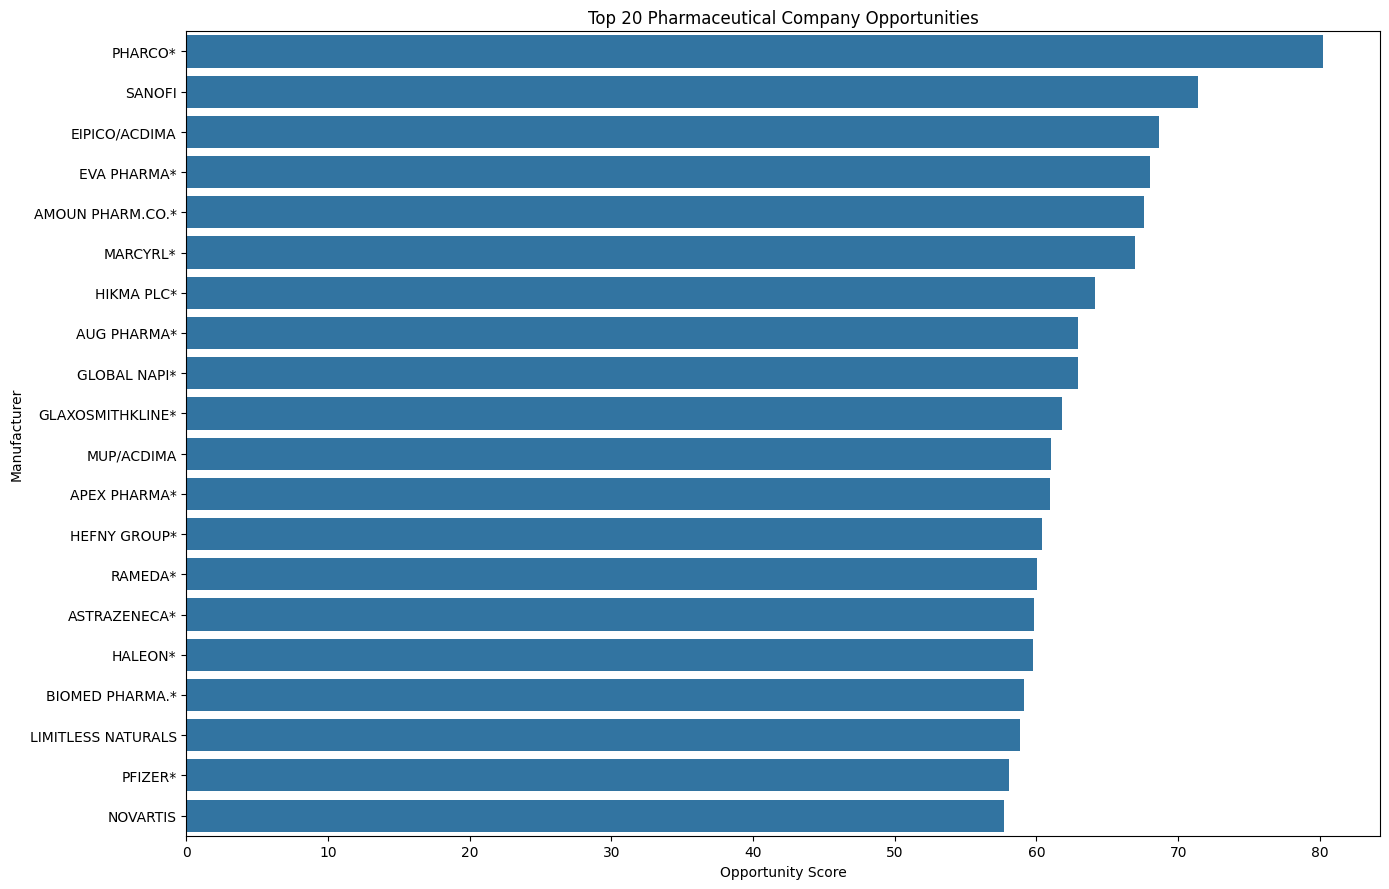

In [60]:
# ============================================================
# 57. TOP COMPANY OPPORTUNITIES
# ============================================================

top_company_opportunities = (
    company_final
    .head(20)
    .copy()
)

plt.figure(figsize=(14, 9))

sns.barplot(
    data=top_company_opportunities,
    y="Manufacturer",
    x="Opportunity_Score"
)

plt.title(
    "Top 20 Pharmaceutical Company Opportunities"
)

plt.xlabel("Opportunity Score")
plt.ylabel("Manufacturer")

plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# 58. EXECUTIVE COMPANY DASHBOARD DATA
# ============================================================

executive_dashboard = {
    "Total_Companies": company_final["Manufacturer"].nunique(),

    "Total_Market_Sales": total_market_sales,

    "Total_Market_Units": total_market_units,

    "Top_Company": (
        company_final
        .sort_values(
            "Sales_Value",
            ascending=False
        )
        .iloc[0]["Manufacturer"]
    ),

    "Top_Company_Market_Share": (
        company_final
        .sort_values(
            "Sales_Value",
            ascending=False
        )
        .iloc[0]["Market_Share_%"]
    ),

    "Company_HHI": HHI_company,

    "Top_5_Company_Share": top5_company_share,

    "Top_10_Company_Share": top10_company_share,

    "Strategic_Leaders": (
        company_final[
            company_final[
                "Company_Strategic_Class"
            ] == "Strategic Leader"
        ]
        .shape[0]
    ),

    "Growth_Challengers": (
        growth_challengers.shape[0]
    )
}

executive_dashboard

{'Total_Companies': 1396,
 'Total_Market_Sales': np.float64(882881495960.4905),
 'Total_Market_Units': np.float64(15310411499.160007),
 'Top_Company': 'PHARCO*',
 'Top_Company_Market_Share': np.float64(4.855196816945325),
 'Company_HHI': np.float64(177.79200299760961),
 'Top_5_Company_Share': np.float64(19.29109681553512),
 'Top_10_Company_Share': np.float64(31.984928074645037),
 'Strategic_Leaders': 349,
 'Growth_Challengers': 24}

In [62]:
# ============================================================
# 58. EXECUTIVE COMPANY DASHBOARD DATA
# ============================================================

executive_dashboard = {
    "Total_Companies": company_final["Manufacturer"].nunique(),

    "Total_Market_Sales": total_market_sales,

    "Total_Market_Units": total_market_units,

    "Top_Company": (
        company_final
        .sort_values(
            "Sales_Value",
            ascending=False
        )
        .iloc[0]["Manufacturer"]
    ),

    "Top_Company_Market_Share": (
        company_final
        .sort_values(
            "Sales_Value",
            ascending=False
        )
        .iloc[0]["Market_Share_%"]
    ),

    "Company_HHI": HHI_company,

    "Top_5_Company_Share": top5_company_share,

    "Top_10_Company_Share": top10_company_share,

    "Strategic_Leaders": (
        company_final[
            company_final[
                "Company_Strategic_Class"
            ] == "Strategic Leader"
        ]
        .shape[0]
    ),

    "Growth_Challengers": (
        growth_challengers.shape[0]
    )
}

executive_dashboard

{'Total_Companies': 1396,
 'Total_Market_Sales': np.float64(882881495960.4905),
 'Total_Market_Units': np.float64(15310411499.160007),
 'Top_Company': 'PHARCO*',
 'Top_Company_Market_Share': np.float64(4.855196816945325),
 'Company_HHI': np.float64(177.79200299760961),
 'Top_5_Company_Share': np.float64(19.29109681553512),
 'Top_10_Company_Share': np.float64(31.984928074645037),
 'Strategic_Leaders': 349,
 'Growth_Challengers': 24}

In [63]:
# ============================================================
# 60. EXPORT COMPANY INTELLIGENCE DATA
# ============================================================

company_final.to_csv(
    "company_intelligence_final.csv",
    index=False
)

top_company_opportunities.to_csv(
    "top_company_opportunities.csv",
    index=False
)

executive_company_table.to_csv(
    "executive_company_intelligence.csv",
    index=False
)

manufacturer_sales.to_csv(
    "manufacturer_sales_analysis.csv",
    index=False
)

company_therapeutic.to_csv(
    "company_therapeutic_analysis.csv",
    index=False
)

company_channel.to_csv(
    "company_channel_analysis.csv",
    index=False
)

print("Company Intelligence files exported successfully.")

Company Intelligence files exported successfully.


In [64]:
# ============================================================
# 61. EXPORT ALL MAJOR RESULTS TO EXCEL
# ============================================================

with pd.ExcelWriter(
    "PharmaLens_Company_Intelligence.xlsx",
    engine="openpyxl"
) as writer:

    company_final.to_excel(
        writer,
        sheet_name="Company Intelligence",
        index=False
    )

    executive_company_table.to_excel(
        writer,
        sheet_name="Executive Top 20",
        index=False
    )

    top_company_opportunities.to_excel(
        writer,
        sheet_name="Opportunities",
        index=False
    )

    manufacturer_sales.to_excel(
        writer,
        sheet_name="Manufacturer Sales",
        index=False
    )

    company_therapeutic.to_excel(
        writer,
        sheet_name="Therapeutic Exposure",
        index=False
    )

    company_channel.to_excel(
        writer,
        sheet_name="Channel Analysis",
        index=False
    )

    strategic_class_distribution.to_excel(
        writer,
        sheet_name="Strategic Classes",
        index=False
    )

    action_distribution.to_excel(
        writer,
        sheet_name="Strategic Actions",
        index=False
    )

print(
    "Excel export completed:"
    " PharmaLens_Company_Intelligence.xlsx"
)

Excel export completed: PharmaLens_Company_Intelligence.xlsx


In [65]:
# ============================================================
# 62. FINAL COMPANY INTELLIGENCE SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("PHARMALENS AI — FINAL COMPANY INTELLIGENCE SUMMARY")
print("=" * 80)

print(
    f"\n1. Companies analyzed: "
    f"{company_final['Manufacturer'].nunique():,}"
)

print(
    f"2. Total market sales: "
    f"{total_market_sales:,.2f}"
)

print(
    f"3. Company market HHI: "
    f"{HHI_company:,.2f}"
)

print(
    f"4. Top 5 companies control: "
    f"{top5_company_share:.2f}% of the market"
)

print(
    f"5. Top 10 companies control: "
    f"{top10_company_share:.2f}% of the market"
)

print(
    f"6. Market leader: "
    f"{company_final.iloc[0]['Manufacturer']}"
)

print(
    f"7. Highest intelligence score: "
    f"{company_final.iloc[0]['Company_Intelligence_Score']:.2f}"
)

print(
    f"8. Highest opportunity company: "
    f"{top_company_opportunities.iloc[0]['Manufacturer']}"
)

print(
    f"9. Highest opportunity score: "
    f"{top_company_opportunities.iloc[0]['Opportunity_Score']:.2f}"
)

print(
    f"10. Strategic leaders: "
    f"{executive_dashboard['Strategic_Leaders']:,}"
)

print(
    f"11. Growth challengers: "
    f"{executive_dashboard['Growth_Challengers']:,}"
)

print("\n")
print("Company Intelligence analysis completed successfully.")
print("=" * 80)



PHARMALENS AI — FINAL COMPANY INTELLIGENCE SUMMARY

1. Companies analyzed: 1,396
2. Total market sales: 882,881,495,960.49
3. Company market HHI: 177.79
4. Top 5 companies control: 19.29% of the market
5. Top 10 companies control: 31.98% of the market
6. Market leader: PHARCO*
7. Highest intelligence score: 66.43
8. Highest opportunity company: PHARCO*
9. Highest opportunity score: 80.23
10. Strategic leaders: 349
11. Growth challengers: 24


Company Intelligence analysis completed successfully.
